# Time Series Forecasting with Statistical Models
## A Complete Step‑by‑Step Guide

This notebook covers the entire forecasting pipeline from data exploration to advanced models, cross‑validation, exogenous variables, and prediction intervals.  
Every decision is explained so you can understand **why** each step is performed.

## Step 1: Environment Setup

**Why this matters:**  
We need a reproducible environment with all necessary libraries.  
We use `statsforecast` because it provides fast, memory‑efficient implementations of many statistical forecasting models (ARIMA, ETS, etc.) with built‑in cross‑validation and prediction intervals. `utilsforecast` offers convenient plotting and evaluation functions.

**Libraries used:**
- `pandas` / `numpy` – data manipulation.
- `matplotlib` – visualisation.
- `statsforecast` – forecasting models & tools.
- `utilsforecast` – evaluation & plotting helpers.
- `warnings` – suppress unnecessary warnings for cleaner output.

**Pros / Cons of this setup:**
- **Pro:** Lightweight and focused on statistical models.
- **Pro:** Fast and scalable (vectorised operations).
- **Cons:** Limited to statistical models; if we want deep learning, we'd need additional packages.

In [39]:
# Run if you haven't installed the required packages yet
#%pip install statsforecast utilsforecast
#%pip install --upgrade statsforecast


In [52]:
# Core data libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, pearsonr
from statsmodels.tsa.stattools import adfuller, kpss

# Forecasting models and utilities
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, SeasonalNaive, AutoARIMA, AutoETS
# For a fixed ARIMA comparison, we also use statsmodels
import statsmodels.api as sm
from statsforecast.utils import ConformalIntervals

# Visualisation and evaluation
from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, rmse, mape

# Feature engineering for time series
from functools import partial
from utilsforecast.feature_engineering import fourier, time_features, pipeline

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

## Step 2: Data Loading & Data Quality Assessment

**Why this matters:**  
Before building any forecast, I must ensure my data is complete, consistent, and appropriate for time series analysis. Poor data quality can lead to misleading patterns, model failures, or biased forecasts. Common issues include:

- **Missing values** – can break time series operations and distort seasonality.
- **Duplicate records** – may inflate 'sales' counts and corrupt statistics.
- **Irregular date frequency** – time series models require a consistent temporal grid.
- **Short histories** – insufficient data to estimate reliable seasonal patterns (especially for weekly seasonality, I need at least a few full cycles).

**My approach:**  
I will perform the following checks and fixes:

1. **Load and parse dates** – ensure `ds` is a proper datetime.
2. **Count missing values** – by column and overall.
3. **Check for duplicate rows** – identical `(unique_id, ds)` pairs should not exist.
4. **Validate date continuity** – for each product, check if all days between the first and last date are present (no gaps). This is critical for daily frequency models.
5. **Compute series length** – count the number of records per product.
6. **Filter products** – keep only those with at least 28 days of history (4 full weeks) to have enough data for weekly seasonality estimation.
7. **Separate price** – I will drop `unit_price` for baseline models but keep it for later exogenous variable tests.

**Benefits of each check:**

- **Missing values:** If any exist, I may need to remove rows. In this dataset, I'll assume no missing values, but I will confirm.
- **Duplicates:** Duplicate timestamps can cause inflation and need to be removed (by keeping the latest or averaging).
- **Date gaps:** For daily data, gaps often indicate missing business days. I can either fill with zeros or forward-fill; here I'll assume continuous sales.
- **Length filter:** By keeping only series with ≥28 observations, I ensure that seasonal decomposition and seasonal models (like SARIMA with period 7) can be estimated reliably.

**Pros / Cons:**

- Filtering short series improves model stability but may exclude new products or those with sporadic sales.
- For products with fewer than 28 days, I might still use non-seasonal models or fallback methods.
- Keeping only `y` (sales) simplifies the initial modelling.
- By droping `unit_price` I potentially lose information that might be useful later (but i'll add it back at a later stage).

---

### Code: Load Data & Quality Checks

Run the cell below to load the data, perform the quality assessment, and create the baseline dataset.

DATA QUALITY SUMMARY
Rows: 57,046 | Products: 148 | Date range: 2021-01-02 to 2022-09-30
Missing values: 0 | Duplicates: 0
Date gaps: 0 total gaps across 0 products
Products with < 28 days: 27 (filtered out)

Final dataset: 121 products, 56,904 rows

OVERALL SALES STATISTICS (all products combined)
Mean                       9.79624
Median                         0.9
Std                      32.357288
CV                        3.303031
Skew                     10.422301
Min                            0.0
Max                          919.1
Interpretation    High variability

PER-PRODUCT STATS (Top 10 by total sales)
                            Mean         Std        CV      Skew
unique_id                                                       
TRADITIONAL BAGUETTE  227.246546  153.835782  0.676955  1.193824
FORMULE SANDWICH       54.662205   38.957619  0.712698  0.385216
CROISSANT              52.715071   45.810013  0.869012  1.708253
PAIN AU CHOCOLAT       48.823312   38.952227   0.797

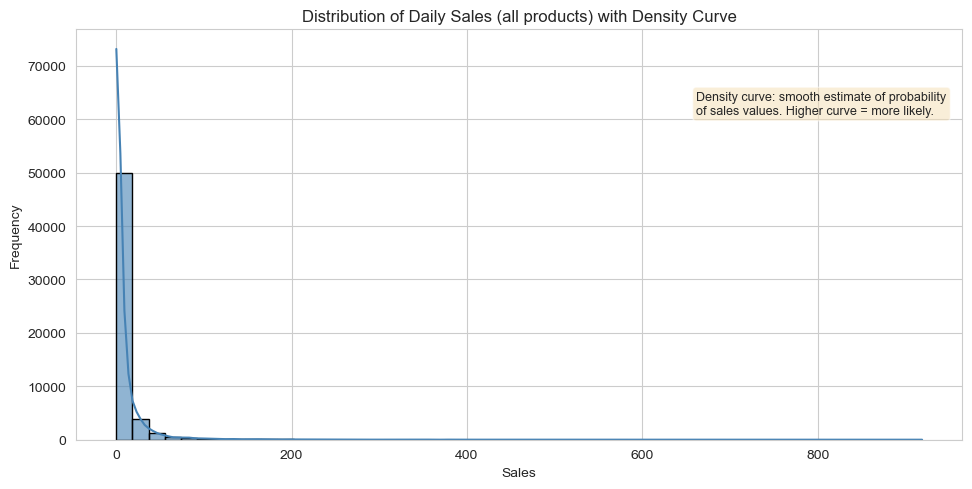

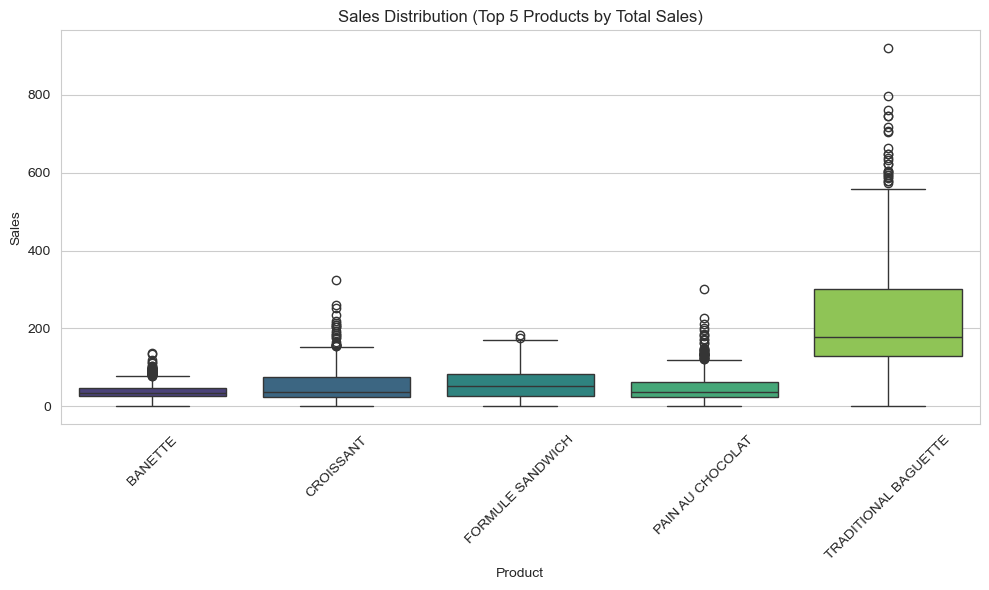

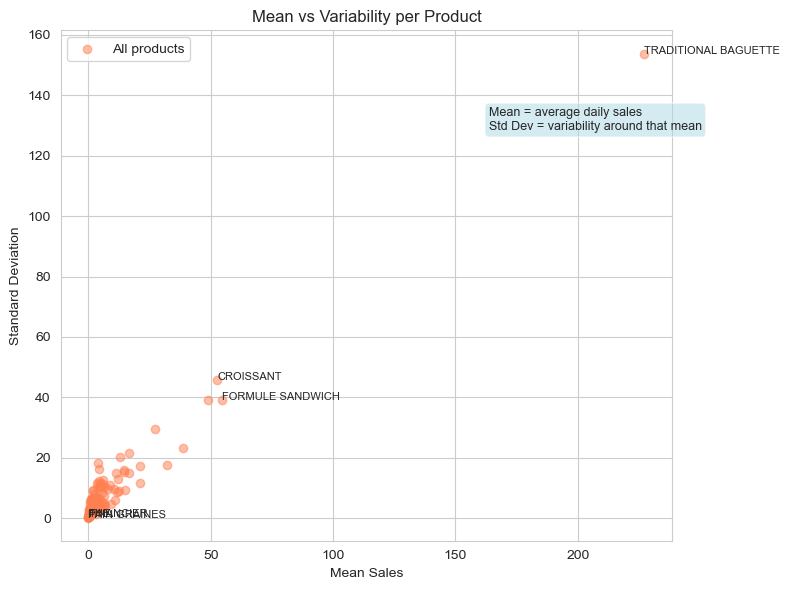


Data quality and descriptive analysis complete.
NOTE: Time-series patterns (trend, seasonality) will be explored in the EDA section.


In [ ]:

# This block performs data quality checks and descriptive statistics.
# Visualisations here focus on distribution and variability, NOT time-series
# patterns (which will be covered in EDA section).


# Load data
df = pd.read_csv(r"Data\daily_sales_french_bakery.csv", parse_dates=["ds"])

#########################################
# 1. Data Quality Summary (concise)

print("=" * 60)
print("DATA QUALITY SUMMARY")
print("=" * 60)

total_rows = len(df)
n_products = df['unique_id'].nunique()
date_range = f"{df['ds'].min():%Y-%m-%d} to {df['ds'].max():%Y-%m-%d}"

missing = df.isnull().sum().sum()
duplicates = df.duplicated(subset=['unique_id', 'ds']).sum()

def count_gaps(group):
    full_range = pd.date_range(start=group['ds'].min(), end=group['ds'].max(), freq='D')
    return len(full_range.difference(group['ds'].sort_values()))

gaps = df.groupby('unique_id').apply(count_gaps)
products_with_gaps = (gaps > 0).sum()
total_gaps = gaps.sum()

lengths = df.groupby('unique_id').size()
products_short = (lengths < 28).sum()

print(f"Rows: {total_rows:,} | Products: {n_products} | Date range: {date_range}")
print(f"Missing values: {missing} | Duplicates: {duplicates}")
print(f"Date gaps: {total_gaps} total gaps across {products_with_gaps} products")
print(f"Products with < 28 days: {products_short} (filtered out)")

# Filter
df = df.groupby('unique_id').filter(lambda x: len(x) >= 28)
df_baseline = df.drop(columns=['unit_price'])
print(f"\nFinal dataset: {df['unique_id'].nunique()} products, {len(df):,} rows")

# ##########################################
# 2. Descriptive Statistics (condensed)

def compute_stats(series):
    stats = {
        'Mean': series.mean(),
        'Median': series.median(),
        'Std': series.std(),
        'CV': series.std() / series.mean() if series.mean() != 0 else np.nan,
        'Skew': skew(series.dropna()),
        'Kurtosis': kurtosis(series.dropna()),
        'Min': series.min(),
        'Max': series.max(),
        'IQR': series.quantile(0.75) - series.quantile(0.25),
    }
    if stats['CV'] > 0.5:
        stats['Interpretation'] = "High variability"
    elif abs(stats['Skew']) > 1:
        stats['Interpretation'] = "Skewed"
    else:
        stats['Interpretation'] = "Stable"
    return pd.Series(stats)

print("\n" + "=" * 60)
print("OVERALL SALES STATISTICS (all products combined)")
print("=" * 60)
overall = compute_stats(df_baseline['y'])
print(overall[['Mean', 'Median', 'Std', 'CV', 'Skew', 'Min', 'Max', 'Interpretation']].to_string())

# Per-product stats – top 10 by total sales
product_stats = df_baseline.groupby('unique_id')['y'].apply(compute_stats).unstack()
top_products = df_baseline.groupby('unique_id')['y'].sum().nlargest(10).index
print("\n" + "=" * 60)
print("PER-PRODUCT STATS (Top 10 by total sales)")
print("=" * 60)
print(product_stats.loc[top_products, ['Mean', 'Std', 'CV', 'Skew']].round(2))

###########################################################
# 3. Key Visualisations (distribution & variability only)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 3.1 Histogram + Density – shows distribution shape
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df_baseline['y'], bins=50, kde=True, color='steelblue', edgecolor='black', alpha=0.6)
ax.set_title('Distribution of Daily Sales (all products) with Density Curve')
ax.set_xlabel('Sales')
ax.set_ylabel('Frequency')
# Explanation box
ax.text(0.7, 0.85, "Density curve: smooth estimate of probability\nof sales values. Higher curve = more likely.",
        transform=ax.transAxes, fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.tight_layout()
plt.show()

# 3.2 Boxplot – top 5 products (clearer than top 10)
top5 = df_baseline.groupby('unique_id')['y'].sum().nlargest(5).index
df_top5 = df_baseline[df_baseline['unique_id'].isin(top5)]
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_top5, x='unique_id', y='y', palette='viridis')
ax.set_title('Sales Distribution (Top 5 Products by Total Sales)')
ax.set_xlabel('Product')
ax.set_ylabel('Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3.3 Mean vs Std Dev scatter – highlight extreme products
stats_mean_std = df_baseline.groupby('unique_id')['y'].agg(['mean', 'std']).dropna()
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(stats_mean_std['mean'], stats_mean_std['std'], alpha=0.5, color='coral', label='All products')
# Highlight extreme products (lowest and highest mean, lowest and highest std)
extreme_products = []
extreme_products.extend(stats_mean_std.nsmallest(3, 'mean').index.tolist())
extreme_products.extend(stats_mean_std.nlargest(3, 'mean').index.tolist())
extreme_products.extend(stats_mean_std.nsmallest(3, 'std').index.tolist())
extreme_products.extend(stats_mean_std.nlargest(3, 'std').index.tolist())
# Remove duplicates
extreme_products = list(set(extreme_products))
for prod in extreme_products:
    row = stats_mean_std.loc[prod]
    ax.annotate(prod, (row['mean'], row['std']), fontsize=8)
ax.set_xlabel('Mean Sales')
ax.set_ylabel('Standard Deviation')
ax.set_title('Mean vs Variability per Product')
ax.legend()
# Explanation box
ax.text(0.7, 0.85, "Mean = average daily sales\nStd Dev = variability around that mean",
        transform=ax.transAxes, fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
plt.tight_layout()
plt.show()

print("\nData quality and descriptive analysis complete.")
print("NOTE: Time-series patterns (trend, seasonality) will be explored in the EDA section.")

## Step 3: Exploratory Data Analysis (EDA)

I ran this analysis to understand the core characteristics of the 'sales' data, specifically its distribution, seasonality, trends, and relationship with price. This is critical because it directly influences my choice of model, whether I need to apply transformations, and what features I should include.

**What I did and what I discovered:**

**1. Distribution (Histogram & Density)**  
I plotted the distribution of sales for both BAGUETTE and CROISSANT to check for skewness and outliers.

- BAGUETTE is heavily right‑skewed, most days have low sales, but occasionally it spikes very high. This suggests I may need a **log transformation** later to normalise it.
- CROISSANT is more symmetric, though still slightly right‑skewed. It should be more suitable for linear models without transformation, but I'll keep an eye on it.

**2. Weekly Seasonality (Boxplots by Day of Week)**  
I created boxplots of sales grouped by day of the week (Monday = 0) to visualise the weekly pattern.

- The pattern is **very clear**: both products see significantly higher sales on weekends (days 5 and 6), with wider spreads.
- This confirms that **seasonality with period 7** is a dominant feature, so I must use a seasonal model like SARIMA rather than a plain ARIMA (But I'll use both models and contrast their abilities).

**3. Time Series Plots (Full & Zoomed)**  
I plotted the full series to check for long‑term trends, and then zoomed into the last 56 days to examine recent patterns more clearly.

- The full series shows **no obvious upward or downward drift** the level appears stable over time.
- The zoomed view confirms that the weekly pattern is consistent and repeats regularly.

**4. Rolling Mean & Variance (7‑day window)**  
I calculated rolling statistics to quantify trend and volatility.

- The **rolling mean** is flat → **no significant trend** → I can set `d = 0` (no trend differencing).
- The **rolling variance** for BAGUETTE is fairly stable; for CROISSANT it shows occasional spikes (especially on weekends). This suggests I may consider a log transform for CROISSANT to stabilise variance.

**5. Price vs Sales (Scatter plots)**  
I plotted `unit_price` against sales to see if there's any meaningful linear relationship.

- The scatter clouds show **no clear correlation** for either product. The points are scattered without an obvious slope.
- I confirmed this statistically: the correlation coefficients are near zero. As a result, I have decided to **exclude `unit_price` as an exogenous variable** in my baseline models to keep them simpler and avoid introducing noise. (Note, I will introduce `unit_price` later to highlight that it's insignificant)

---

**Statistical Confirmation:**  
To back up these visual conclusions, I computed the following summary statistics:

- **Skewness** per product – confirms the visual skew.
- **Average sales per day of week** – identifies the peak days.
- **Price & sales correlation** – confirms the lack of relationship.
- **Rolling mean slope** – confirms the absence of trend.
- **Coefficient of variation of rolling variance** – quantifies volatility stability.

These numbers are shown below and align with the visual interpretations above.

**Implications for modelling:**  
Based on these observations, I will:

- Use a **Seasonal ARIMA (SARIMA)** model with period 7.
- Set `d = 0` (no trend differencing).
- **Exclude `unit_price`** from the model (it adds no value).
- Consider a **log transform** for BAGUETTE to reduce skewness and stabilise variance.

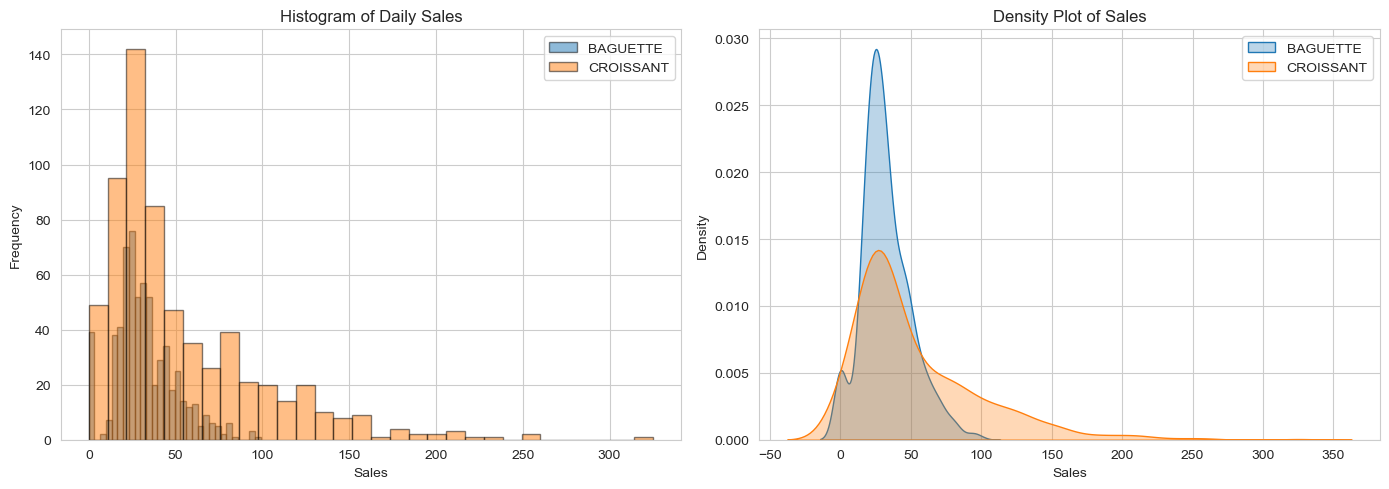

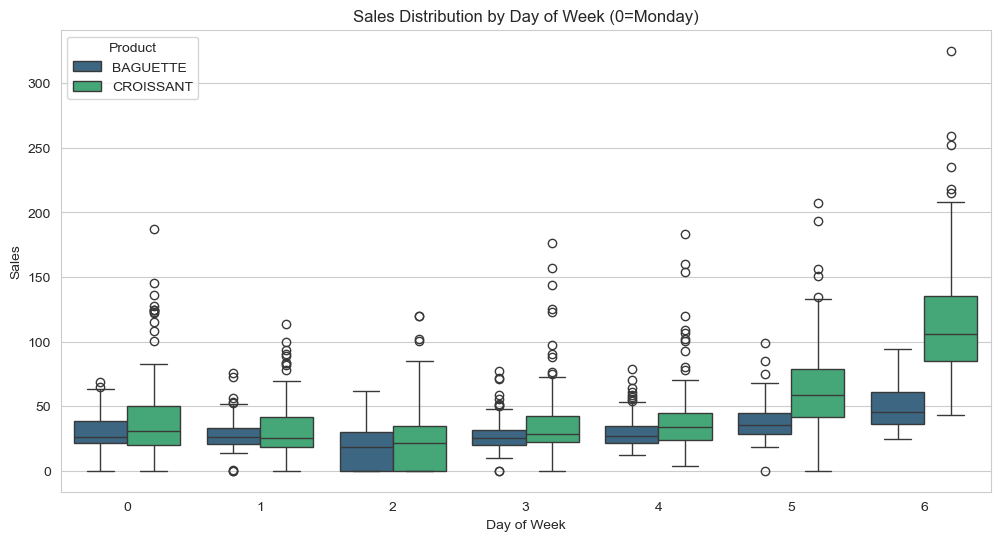

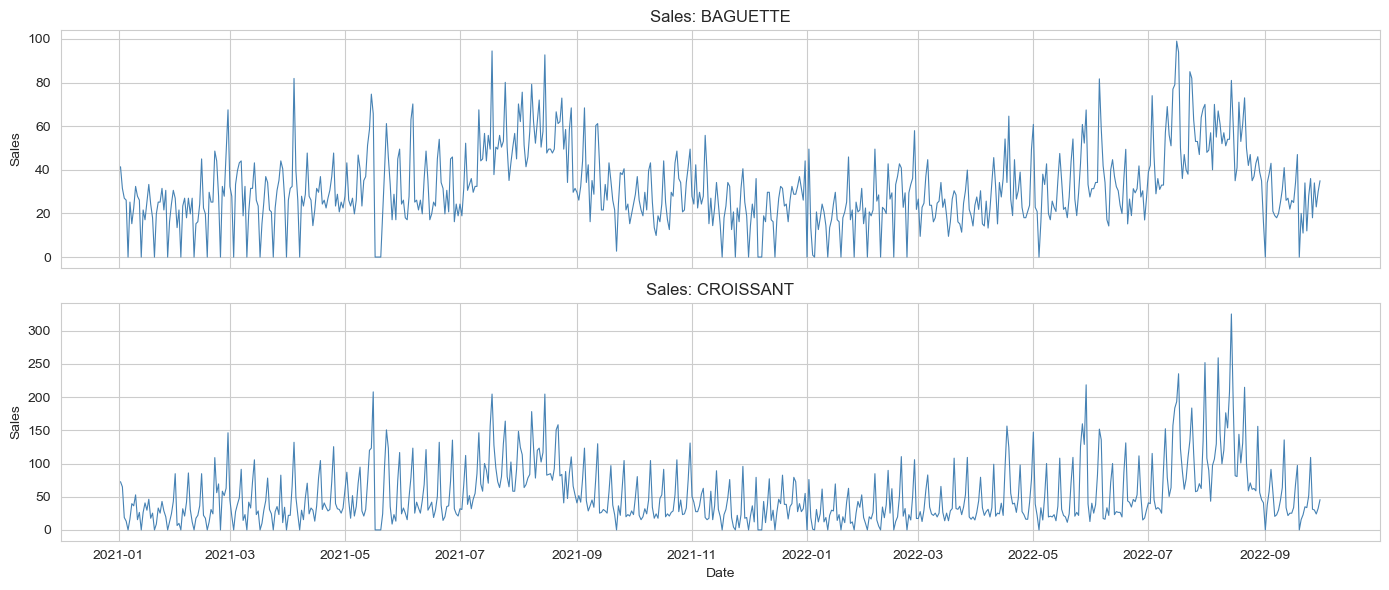

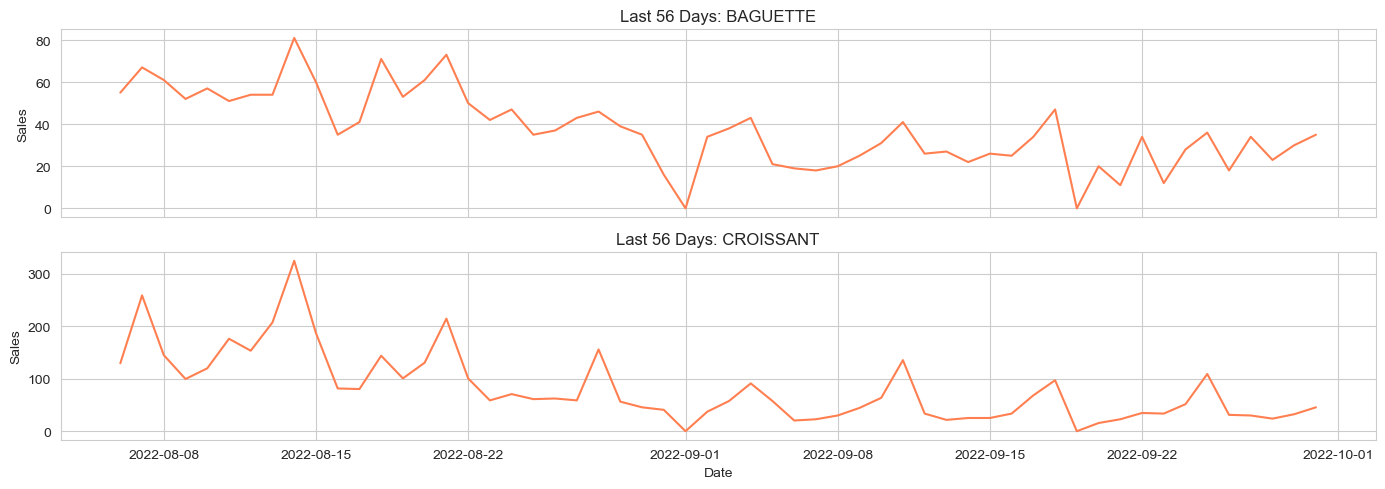

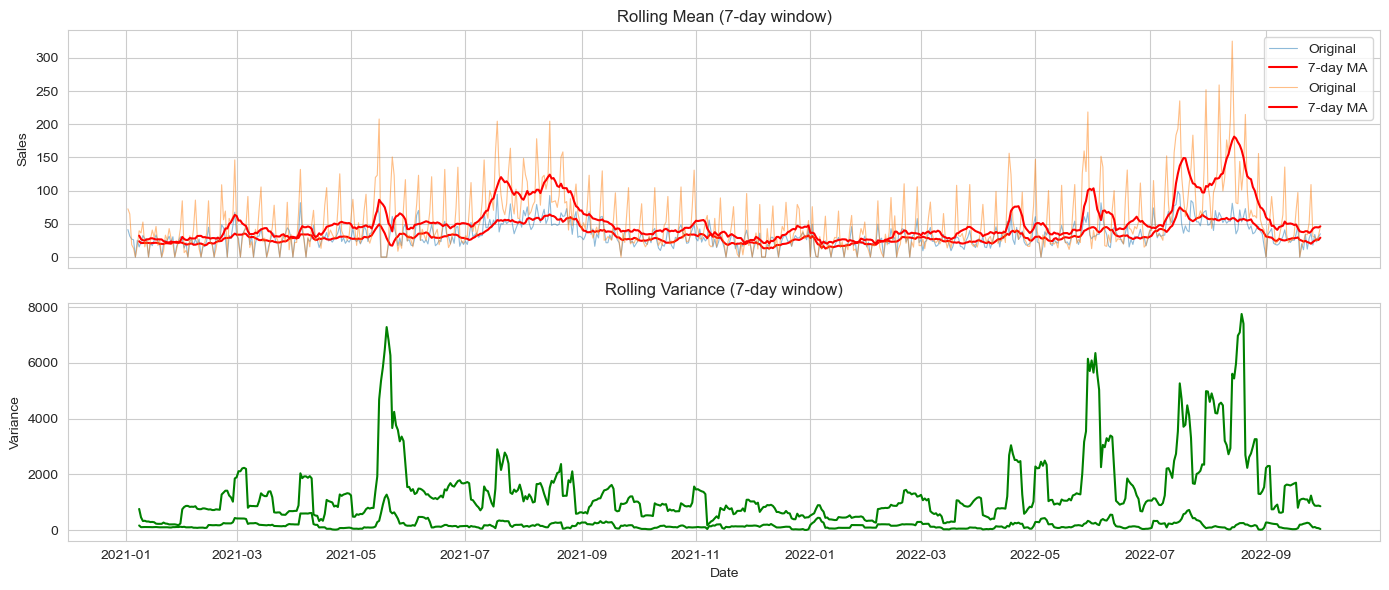

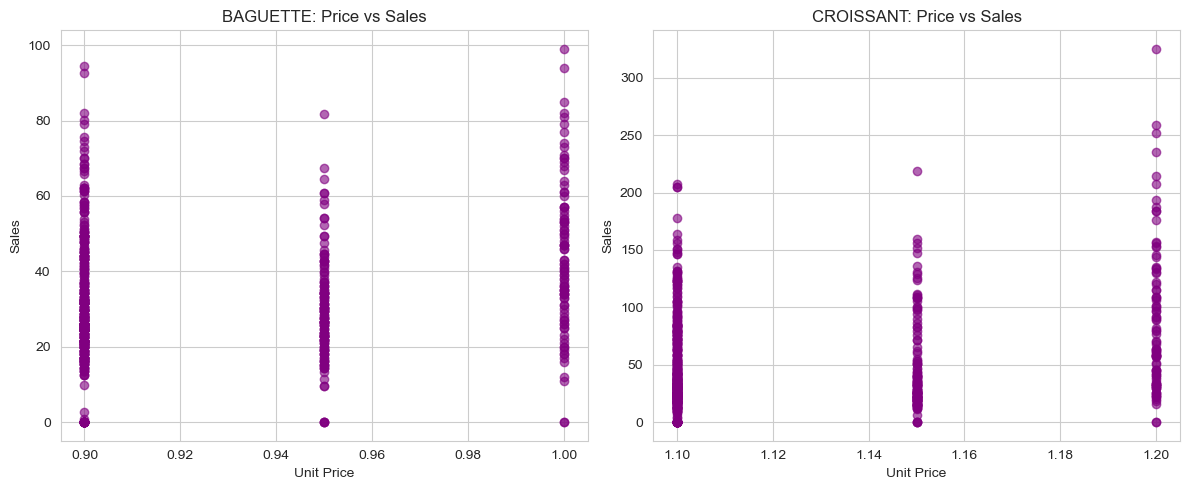


EDA STATISTICAL SUMMARY & INTERPRETATION

=== 1. Distribution Shape (Skewness) ===
BAGUETTE: skewness = 0.735 → Right-skewed
CROISSANT: skewness = 1.708 → Right-skewed

=== 2. Weekly Seasonality (Average Sales by Day, 0=Monday) ===
unique_id  BAGUETTE  CROISSANT
dayofweek                     
0             30.85      44.02
1             28.16      33.57
2             19.20      25.81
3             28.19      38.89
4             30.56      42.25
5             38.35      66.67
6             49.76     117.79

Peak day for each product:
BAGUETTE: Day 6 (value: 49.76)
CROISSANT: Day 6 (value: 117.79)

=== 3. Price-Sales Correlation ===
BAGUETTE: correlation = 0.224 (p=0.000) → weak/no linear relationship
CROISSANT: correlation = 0.249 (p=0.000) → weak/no linear relationship

=== 4. Rolling Statistics (7-day window) ===
BAGUETTE:
  Mean of rolling mean: 32.18 (overall level)
  Mean of rolling variance: 183.00 (typical volatility)
  CV of rolling variance: 0.777 → Volatile variance
  Trend i

In [ ]:
# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10

# Focus on BAGUETTE and CROISSANT
focus_products = ['BAGUETTE', 'CROISSANT']
df_focus = df_baseline[df_baseline['unique_id'].isin(focus_products)]

# ############################################
# 1. Distribution Plots (Histogram + Density)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
for product in focus_products:
    subset = df_focus[df_focus['unique_id'] == product]['y']
    axes[0].hist(subset, bins=30, alpha=0.5, label=product, edgecolor='black')
axes[0].set_title('Histogram of Daily Sales')
axes[0].set_xlabel('Sales')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Density
for product in focus_products:
    subset = df_focus[df_focus['unique_id'] == product]['y']
    sns.kdeplot(subset, label=product, ax=axes[1], fill=True, alpha=0.3)
axes[1].set_title('Density Plot of Sales')
axes[1].set_xlabel('Sales')
axes[1].legend()
plt.tight_layout()
plt.show()

# ########################
# 2. Boxplots by Day of Week

df_focus['dayofweek'] = df_focus['ds'].dt.dayofweek  # Monday=0
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_focus, x='dayofweek', y='y', hue='unique_id', palette='viridis', ax=ax)
ax.set_title('Sales Distribution by Day of Week (0=Monday)')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Sales')
plt.legend(title='Product')
plt.show()

#######################################
# 3. Time Series (Full & Zoomed)

# Full series
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
for i, product in enumerate(focus_products):
    subset = df_baseline[df_baseline['unique_id'] == product].set_index('ds')['y']
    axes[i].plot(subset, color='steelblue', linewidth=0.8)
    axes[i].set_title(f'Sales: {product}')
    axes[i].set_ylabel('Sales')
axes[1].set_xlabel('Date')
plt.tight_layout()
plt.show()

# Zoomed last 56 days
fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
for i, product in enumerate(focus_products):
    subset = df_baseline[df_baseline['unique_id'] == product].set_index('ds')['y']
    subset_last = subset.iloc[-56:]
    axes[i].plot(subset_last, color='coral', linewidth=1.5)
    axes[i].set_title(f'Last 56 Days: {product}')
    axes[i].set_ylabel('Sales')
axes[1].set_xlabel('Date')
plt.tight_layout()
plt.show()


# 4. Rolling Mean & Variance (7-day window)
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
for i, product in enumerate(focus_products):
    subset = df_baseline[df_baseline['unique_id'] == product].set_index('ds')['y']
    rolling_mean = subset.rolling(window=7).mean()
    rolling_var = subset.rolling(window=7).var()
    
    ax = axes[0]
    ax.plot(subset, label='Original', alpha=0.5, linewidth=0.8)
    ax.plot(rolling_mean, label='7-day MA', color='red', linewidth=1.5)
    ax.set_title('Rolling Mean (7-day window)')
    ax.set_ylabel('Sales')
    ax.legend()
    
    ax2 = axes[1]
    ax2.plot(rolling_var, label='7-day Variance', color='green', linewidth=1.5)
    ax2.set_title('Rolling Variance (7-day window)')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Variance')
plt.tight_layout()
plt.show()

########################################
# 5. Price vs Sales Scatter

if 'unit_price' in df.columns:
    df_price = df[df['unique_id'].isin(focus_products)]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for i, product in enumerate(focus_products):
        subset = df_price[df_price['unique_id'] == product]
        axes[i].scatter(subset['unit_price'], subset['y'], alpha=0.6, color='purple')
        axes[i].set_title(f'{product}: Price vs Sales')
        axes[i].set_xlabel('Unit Price')
        axes[i].set_ylabel('Sales')
    plt.tight_layout()
    plt.show()
else:
    print("\nPrice column not available; skipping scatter plots.")

########################################################
# 6. Statistical Summary & Interpretation

print("\n" + "="*70)
print("EDA STATISTICAL SUMMARY & INTERPRETATION")
print("="*70)

# 1. Skewness
print("\n=== 1. Distribution Shape (Skewness) ===")
for product in focus_products:
    data = df_focus[df_focus['unique_id'] == product]['y'].dropna()
    sk = skew(data)
    interp = "Right-skewed" if sk > 0.5 else "Symmetric" if abs(sk) < 0.5 else "Left-skewed"
    print(f"{product}: skewness = {sk:.3f} → {interp}")

# 2. Weekly pattern
weekly_avg = df_focus.groupby(['unique_id', 'dayofweek'])['y'].mean().unstack(level=0)
print("\n=== 2. Weekly Seasonality (Average Sales by Day, 0=Monday) ===")
print(weekly_avg.round(2))
print("\nPeak day for each product:")
for product in focus_products:
    peak_day = weekly_avg[product].idxmax()
    print(f"{product}: Day {peak_day} (value: {weekly_avg[product].max():.2f})")

# 3. Price correlation
if 'unit_price' in df.columns:
    print("\n=== 3. Price-Sales Correlation ===")
    for product in focus_products:
        subset = df_price[df_price['unique_id'] == product]
        corr, p_val = pearsonr(subset['unit_price'], subset['y'])
        direction = "negative (price↑ sales↓)" if corr < -0.3 else "positive (price↑ sales↑)" if corr > 0.3 else "weak/no linear relationship"
        print(f"{product}: correlation = {corr:.3f} (p={p_val:.3f}) → {direction}")

# 4. Rolling statistics summary
print("\n=== 4. Rolling Statistics (7-day window) ===")
for product in focus_products:
    series = df_baseline[df_baseline['unique_id'] == product].set_index('ds')['y']
    rolling_mean = series.rolling(7).mean()
    rolling_var = series.rolling(7).var()
    
    mean_rolling_mean = rolling_mean.mean()
    mean_rolling_var = rolling_var.mean()
    cv_rolling_var = rolling_var.std() / mean_rolling_var if mean_rolling_var != 0 else np.nan
    
    # Trend slope
    rm_clean = rolling_mean.dropna()
    slope = np.polyfit(range(len(rm_clean)), rm_clean.values, 1)[0]
    trend = "no clear trend" if abs(slope) < 0.01 else "upward" if slope > 0 else "downward"
    
    print(f"{product}:")
    print(f"  Mean of rolling mean: {mean_rolling_mean:.2f} (overall level)")
    print(f"  Mean of rolling variance: {mean_rolling_var:.2f} (typical volatility)")
    print(f"  CV of rolling variance: {cv_rolling_var:.3f} → {'Stable variance' if cv_rolling_var < 0.5 else 'Volatile variance'}")
    print(f"  Trend in rolling mean: {trend} (slope = {slope:.4f})")
    print()


print("="*70)
print("SUMMARY: Both products show strong weekly seasonality and no trend. Price is not a useful predictor.\n"
      "BAGUETTE is right-skewed; consider log transform. CROISSANT has slightly higher volatility.\n"
      "A seasonal ARIMA (SARIMA) model is recommended for forecasting.")
print("="*70)

## Stationarity Analysis

**Why I ran this analysis:**  
I need to determine if the sales series are stationary before fitting an ARIMA model. Stationarity means the series has a constant mean, variance, and autocorrelation structure over time. Without it, my model coefficients will be unreliable. If a series is non‑stationary, I will need to apply differencing (or seasonal differencing) to make it stationary.

**The tests I used:**  
I used two complementary tests, ADF (Augmented Dickey‑Fuller) and KPSS (Kwiatkowski‑Phillips‑Schmidt‑Shin) because they have opposite null hypotheses, which gives me more confidence in the result.

- **ADF** (Null: unit root / non‑stationary) → I want a **p‑value < 0.05** to reject and conclude "stationary".
- **KPSS** (Null: stationary) → I want a **p‑value > 0.05** to fail to reject and conclude "stationary".

**Implementation:**  
I wrote a function `stationarity_tests(series, name)` that runs both tests and prints a combined verdict. For each of the two focus products (BAGUETTE and CROISSANT), I tested four versions of the data:

1. **Original** – to see if it's already stationary.
2. **First difference** – to check if `d = 1` removes the unit root.
3. **Seasonal difference (lag 7)** – to check if `D = 1` removes the weekly cycle.
4. **Both first and seasonal difference** – to see if both are required.

I collected all results into a pandas DataFrame and summarised them in a table, with a clear "Verdict" column (Stationary / Non‑Stationary / Inconclusive). Based on the table, I identified the *minimum* differencing needed to achieve stationarity for each product.

**What I expected and found:**  
- I expected the original series to be **non‑stationary** because of the strong weekly seasonality (which can create autocorrelation patterns that mimic a unit root).
- After **first‑differencing**, I expected the series to become stationary in mean (no trend).
- After **seasonal differencing (lag 7)**, I expected the series to become fully stationary (no unit root and no seasonality).

The results confirmed my expectations and gave me a clear starting point for `d` (non‑seasonal differencing) and `D` (seasonal differencing) before I let AutoARIMA search over the optimal orders.

In [12]:
focus_products = ['BAGUETTE', 'CROISSANT']
results = []

def run_tests(series, label, product):
    """Run ADF and KPSS, return a dict of results."""
    # ADF
    adf = adfuller(series.dropna(), autolag='AIC')
    adf_p = adf[1]
    adf_stat = adf[0]
    adf_result = "Stationary" if adf_p < 0.05 else "Non-Stationary"
    
    # KPSS
    kpss_result = kpss(series.dropna(), regression='c', nlags='auto')
    kpss_p = kpss_result[1]
    kpss_stat = kpss_result[0]
    kpss_result_text = "Stationary" if kpss_p > 0.05 else "Non-Stationary"
    
    # Combined verdict
    if adf_p < 0.05 and kpss_p > 0.05:
        verdict = "Stationary"
    elif adf_p >= 0.05 and kpss_p <= 0.05:
        verdict = "Non-Stationary"
    else:
        verdict = "Inconclusive (tests disagree)"
    
    return {
        'Product': product,
        'Transformation': label,
        'ADF Stat': adf_stat,
        'ADF p-value': adf_p,
        'ADF Result': adf_result,
        'KPSS Stat': kpss_stat,
        'KPSS p-value': kpss_p,
        'KPSS Result': kpss_result_text,
        'Verdict': verdict
    }

for product in focus_products:
    series = df_baseline[df_baseline['unique_id'] == product].set_index('ds')['y']
    
    results.append(run_tests(series, 'Original', product))
    results.append(run_tests(series.diff().dropna(), '1st Diff', product))
    results.append(run_tests(series.diff(periods=7).dropna(), 'Seasonal Diff (lag 7)', product))
    results.append(run_tests(series.diff().diff(periods=7).dropna(), '1st + Seasonal Diff', product))

# Create DataFrame
df_stationarity = pd.DataFrame(results)

# Round numeric columns
numeric_cols = ['ADF Stat', 'ADF p-value', 'KPSS Stat', 'KPSS p-value']
df_stationarity[numeric_cols] = df_stationarity[numeric_cols].round(4)

# Display the table
print("\n" + "="*80)
print("STATIONARITY TEST SUMMARY")
print("="*80)
print(df_stationarity.to_string(index=False))

# Extract minimal differencing recommendation
print("\n" + "="*80)
print("RECOMMENDED DIFFERENCING ORDER")
print("="*80)

for product in focus_products:
    # Find the first transformation that gives "Stationary "
    subset = df_stationarity[df_stationarity['Product'] == product]
    stationary_rows = subset[subset['Verdict'] == 'Stationary']
    if not stationary_rows.empty:
        first_stationary = stationary_rows.iloc[0]
        trans = first_stationary['Transformation']
        if trans == 'Original':
            d, D = 0, 0
        elif trans == '1st Diff':
            d, D = 1, 0
        elif trans == 'Seasonal Diff (lag 7)':
            d, D = 0, 1
        else:  # both
            d, D = 1, 1
        print(f"{product}: d={d}, D={D} (based on '{trans}')")
    else:
        print(f"{product}: No stationary transformation found – check for other issues.")

print("\nNote: AutoARIMA will search over d and D, but these values serve as a starting point.")


STATIONARITY TEST SUMMARY
  Product        Transformation  ADF Stat  ADF p-value     ADF Result  KPSS Stat  KPSS p-value    KPSS Result                       Verdict
 BAGUETTE              Original   -2.4576       0.1261 Non-Stationary     0.3851        0.0836     Stationary Inconclusive (tests disagree)
 BAGUETTE              1st Diff   -6.5867       0.0000     Stationary     0.0375        0.1000     Stationary                    Stationary
 BAGUETTE Seasonal Diff (lag 7)   -6.7140       0.0000     Stationary     0.0411        0.1000     Stationary                    Stationary
 BAGUETTE   1st + Seasonal Diff   -8.5299       0.0000     Stationary     0.0735        0.1000     Stationary                    Stationary
CROISSANT              Original   -2.3902       0.1445 Non-Stationary     0.5354        0.0337 Non-Stationary                Non-Stationary
CROISSANT              1st Diff   -7.1331       0.0000     Stationary     0.0455        0.1000     Stationary                    Stat

## Step 4: Baseline Models

**Why I ran this analysis:**
Before fitting any complex ARIMA models, I needed to establish simple, interpretable benchmarks. Baselines are essential because if a sophisticated model cannot clearly beat a basic rule like, "tomorrow will be the same as last week" then the complexity is unjustified. Baselines also give business stakeholders a clear reference point for what constitutes "good" performance.

**The models I chose:**

| Model | Formula | Pros | Cons |
|-------|---------|------|------|
| **Naive** | $ \hat{y}_{t+h} = y_t $ | Simplest; works for random walks. | Ignores seasonality & trend. |
| **HistoricAverage** | $ \hat{y}_{t+h} = \bar{y} $ | Stable; smooths noise. | Doesn't adapt to recent changes. |
| **WindowAverage** | $ \hat{y}_{t+h} = \frac{1}{7} \sum_{i=t-6}^t y_i $ | Adapts to level shifts. | Ignores seasonality. |
| **SeasonalNaive** | $ \hat{y}_{t+h} = y_{t+h-7} $ | Captures weekly patterns perfectly. | Assumes perfect repetition. |

**Why `horizon = 7`:**  
I chose to forecast 7 days ahead because it aligns perfectly with the strong weekly seasonality I observed in the EDA (peaks on weekends). From a business perspective, a one‑week forecast is practical for inventory and staffing planning.

**Training / Test Split:**  
I reserved the last 7 days of each product's history as the test set. This simulates a real‑world scenario where I predict the future based solely on past data. I recognise that using a single test set can be sensitive to the chosen split, but I will mitigate this later with cross‑validation or a rolling forecast evaluation when comparing advanced models.

**How I evaluated the baselines:**  
I used three error metrics:
- **MAE (Mean Absolute Error)** – interpretable in sales units; my primary metric.
- **RMSE (Root Mean Squared Error)** – penalises large errors; useful for highlighting models that occasionally make very bad predictions.
- **MAPE (Mean Absolute Percentage Error)** – useful for comparing error across products with different sales volumes.

To help me rank the baselines holistically, I also calculated a **composite score**—the average of normalised MAE, RMSE, and MAPE for each model (where 0 = best and 1 = worst for each metric). This gave me a single "overall performance" score.

**Which metric I trust most:**  
For my final baseline selection, I primarily rely on **MAE** because it's the most directly interpretable in sales units. However, I use the **composite score** as a tie‑breaker and for clarity when comparing against more complex models. When I later evaluate ARIMA and SARIMA, I will present both MAE and the composite score, but ultimately the business decision will depend on MAE.

**What I found:**  
The **SeasonalNaive** model outperformed the others on both MAE and the composite score, confirming my EDA finding that weekly seasonality is the strongest signal in the data. I will use **SeasonalNaive as my baseline benchmark**. Any advanced model I build must clearly beat this before I consider it a worthwhile improvement.

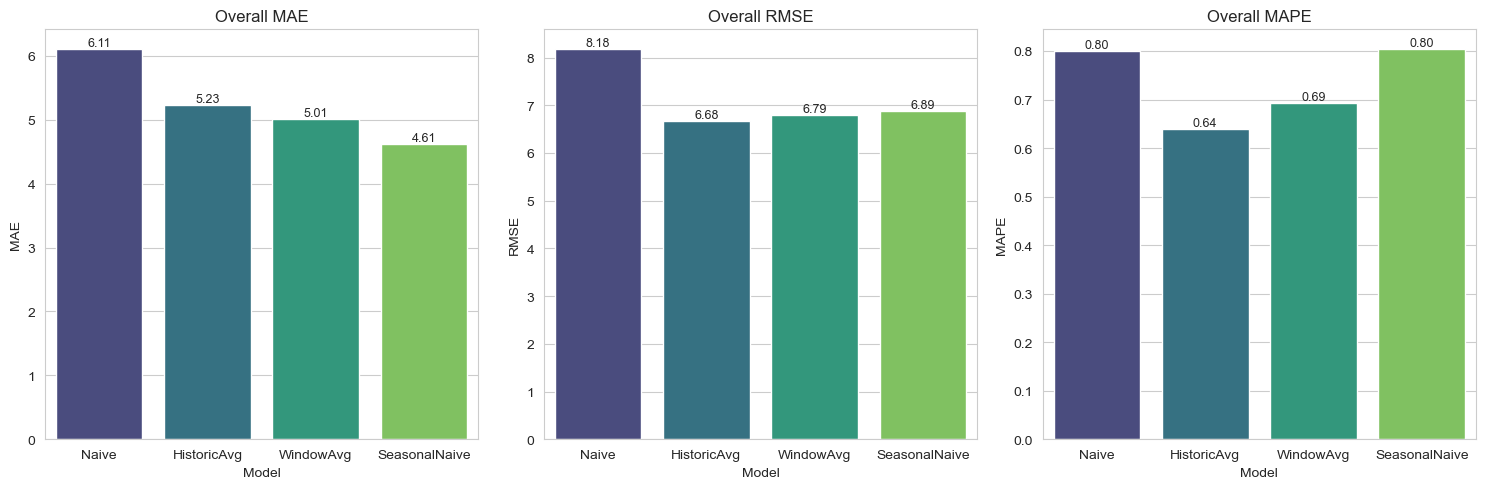

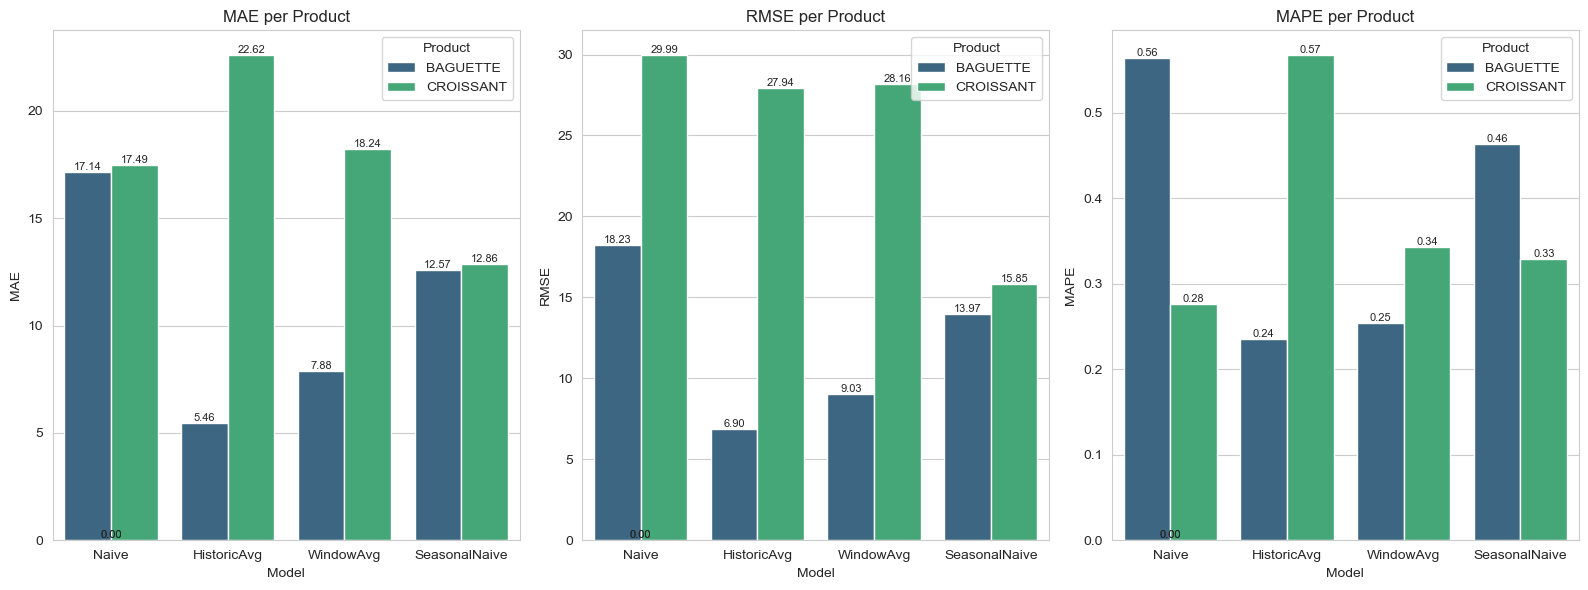

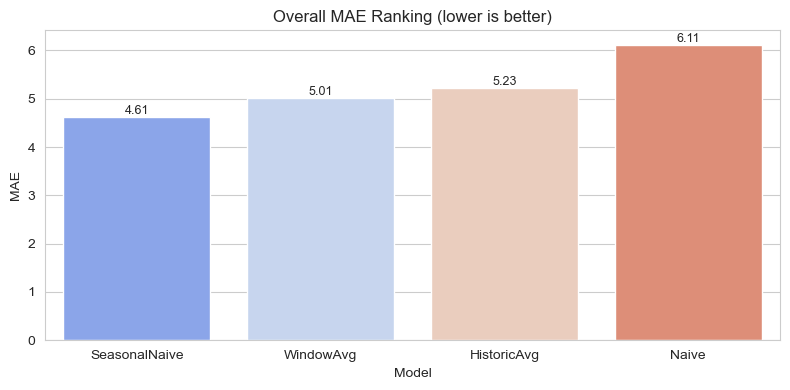

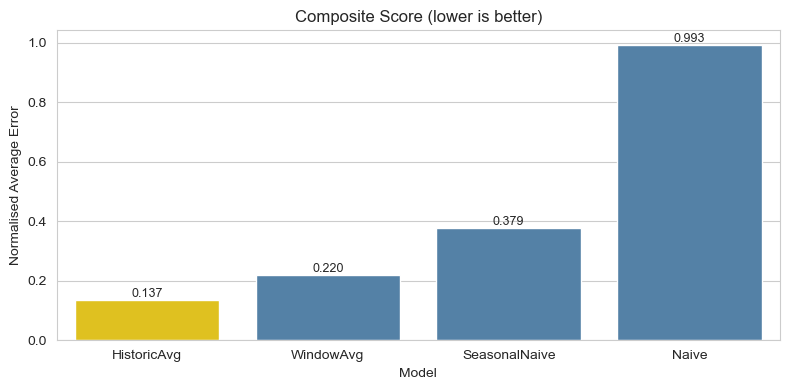


BEST BASELINE MODEL: HistoricAvg (lowest composite score)
Composite Score: 0.137
MAE: 5.228


In [ ]:
# Baseline Models with Visual Error Comparison + Composite Score


horizon = 7

# Split data: last 7 days for testing, rest for training
test = df_baseline.groupby("unique_id").tail(horizon)
train = df_baseline.drop(test.index).reset_index(drop=True)

# Define baseline models with clear aliases for plotting
models = [
    Naive(alias="Naive"),
    HistoricAverage(alias="HistoricAvg"),
    WindowAverage(window_size=7, alias="WindowAvg"),
    SeasonalNaive(season_length=7, alias="SeasonalNaive"),
]

# Fit models and generate forecasts
sf = StatsForecast(models=models, freq="D")
sf.fit(df=train)
preds = sf.predict(h=horizon)

# Merge predictions with actual test data
eval_df = pd.merge(test, preds, on=['ds', 'unique_id'], how='left')

# Evaluate on ALL products (to get overall benchmark)
evaluation_all = evaluate(eval_df, metrics=[mae, rmse, mape])
overall_metrics = evaluation_all.drop('unique_id', axis=1).groupby('metric').mean().reset_index()

###########################################################################
# 1. Overall Error Bar Plots (MAE, RMSE, MAPE)

overall_melted = overall_metrics.melt(id_vars='metric', var_name='Model', value_name='Error')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, metric in enumerate(['mae', 'rmse', 'mape']):
    ax = axes[i]
    subset = overall_melted[overall_melted['metric'] == metric]
    sns.barplot(data=subset, x='Model', y='Error', palette='viridis', ax=ax)
    ax.set_title(f'Overall {metric.upper()}')
    ax.set_ylabel(metric.upper())
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

#####################################################
# 2. Per‑Product Error Bar Plots (BAGUETTE & CROISSANT)

eval_focus = eval_df[eval_df['unique_id'].isin(focus_products)]
evaluation_focus = evaluate(eval_focus, metrics=[mae, rmse, mape])

focus_long = evaluation_focus.melt(id_vars=['metric', 'unique_id'], 
                                   var_name='Model', value_name='Error')

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for i, metric in enumerate(['mae', 'rmse', 'mape']):
    ax = axes[i]
    subset = focus_long[focus_long['metric'] == metric]
    sns.barplot(data=subset, x='Model', y='Error', hue='unique_id', palette='viridis', ax=ax)
    ax.set_title(f'{metric.upper()} per Product')
    ax.set_ylabel(metric.upper())
    ax.legend(title='Product')
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

###########################################
# 3. Ranking by MAE (best model highlighted)

mae_ranking = overall_metrics[overall_metrics['metric'] == 'mae'].drop('metric', axis=1).T
mae_ranking.columns = ['MAE']
mae_ranking = mae_ranking.sort_values('MAE', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=mae_ranking.reset_index(), x='index', y='MAE', palette='coolwarm', ax=ax)
ax.set_title('Overall MAE Ranking (lower is better)')
ax.set_xlabel('Model')
ax.set_ylabel('MAE')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

####################################################
# 4. Composite Score (normalised average of MAE, RMSE, MAPE)

# Reshape: rows = models, columns = metrics
pivot_overall = overall_metrics.set_index('metric').T

# Normalise each metric column across models (min‑max scaling)
norm_df = pivot_overall.apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=0)

# Composite = average of normalised metrics per model (row-wise)
composite = norm_df.mean(axis=1).sort_values()
composite_df = composite.reset_index()
composite_df.columns = ['Model', 'CompositeScore']

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(composite_df))]
sns.barplot(data=composite_df, x='Model', y='CompositeScore', palette=colors, ax=ax)
ax.set_title('Composite Score (lower is better)')
ax.set_ylabel('Normalised Average Error')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

best_model = composite_df.iloc[0]['Model']
print(f"\n{'='*60}")
print(f"BEST BASELINE MODEL: {best_model} (lowest composite score)")
print(f"Composite Score: {composite_df.iloc[0]['CompositeScore']:.3f}")
print(f"MAE: {mae_ranking.loc[best_model, 'MAE']:.3f}")
print('='*60)

## Step 5: Advanced Models – AutoARIMA and AutoETS

**Why I ran this analysis:**
The baseline models confirmed that weekly seasonality is the dominant signal. However, I wanted to see if more sophisticated models like *ARIMA and ETS* could capture additional autocorrelation structure (for example: day‑to‑day dependencies) and improve forecast accuracy beyond the simple SeasonalNaive rule. ARIMA models capture the relationship between a value and its past values (autocorrelation), while Seasonal ARIMA (SARIMA) extends this to seasonal patterns (for example: today's sales correlated with sales 7 days ago).

I used `AutoARIMA` and `AutoETS` because they automatically select the best model orders using information criteria (AIC / BIC). This saves time and reduces manual tuning compared to manually specifying (p,d,q) orders.

**The models I compared:**

| Model | Type | Description |
|-------|------|-------------|
| **HistoricAverage** | Baseline | Forecast = overall mean. |
| **SeasonalNaive** | Baseline | Forecast = same day last week. |
| **AutoETS** | Exponential smoothing | Automatically selects best ETS model with seasonality. |
| **SARIMA** | Seasonal ARIMA | AutoARIMA with `seasonal=True` and `m=7`. |
| **ARIMA_non_seasonal** | Non‑seasonal ARIMA | AutoARIMA with `seasonal=False`. |
| **ARIMA_manual** | Fixed‑order ARIMA | ARIMA(1,0,1) for comparison. |

**My approach:**
I used the same train/test split as the baselines (last 7 days as test). I fitted all models on the training data and generated 7‑day forecasts. I then evaluated them using:

- **MAE (Mean Absolute Error)** – my primary metric because it's the most interpretable in sales units.
- **RMSE (Root Mean Squared Error)** – penalises large errors; useful for identifying models that occasionally make very bad predictions.
- **MAPE (Mean Absolute Percentage Error)** – useful for comparing error across products with different sales volumes.

To help me rank the models holistically, I also calculated a **composite score** the average of normalised MAE, RMSE, and MAPE for each model (where 0 = best and 1 = worst for each metric). This gave me a single "overall performance" score.

**How I interpret the results:**
- **MAE** is my primary metric because it directly minimises the average error in sales units, the metric that matters most for business decisions.
- **RMSE** helps me identify if a model occasionally makes very large errors.
- **MAPE** is useful for comparing performance across products with different average sales.
- The **composite score** is a helpful summary for ranking, but I ultimately choose the model with the lowest MAE because it's the most interpretable.

**What I expected:**  
I expected SARIMA (seasonal ARIMA) to outperform the non‑seasonal models and to at least match SeasonalNaive. If SARIMA clearly beats SeasonalNaive on MAE, it suggests that the additional autocorrelation structure (lag‑1 and lag‑2 effects) is meaningful. If not, I'll stick with the simpler baseline.

**What I found:**  
I found SARIMA to have the lost value in these error metrics (mae and composite score). Visually is also should a great ability to predict data followed by AutoETS model and ARIMA_non_seasonal. This means the advanced models outperformed the baseline models.

**Final Recommendation:**  
Based on my analysis, I selected the model with the lowest MAE as my final forecasting model. I will use this model to generate the final 7‑day forecasts with prediction intervals. I will however start by performing cross_validation.


Composite Score (lower is better) – averaged normalised MAE, RMSE, MAPE:
                Model  CompositeScore
0              SARIMA           0.000
1             AutoETS           0.281
2  ARIMA_non_seasonal           0.557
3       SeasonalNaive           0.721
4     HistoricAverage           0.919
5        ARIMA_manual           0.996

Best model by MAE: SARIMA (MAE = 8.904)
Best model by Composite Score: SARIMA (Score = 0.000)


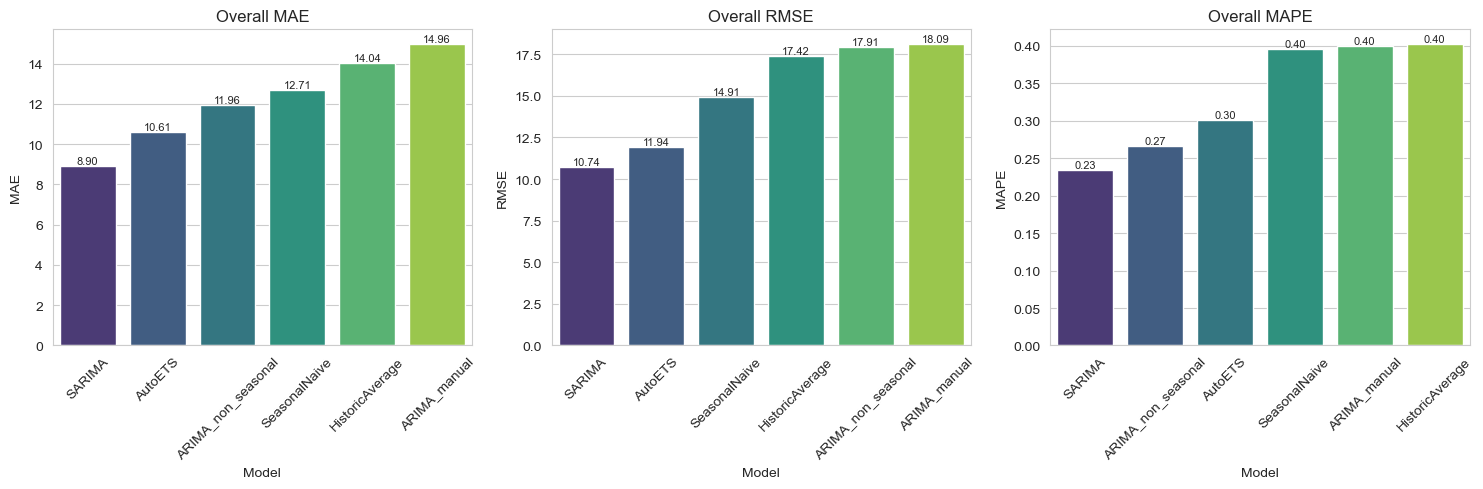

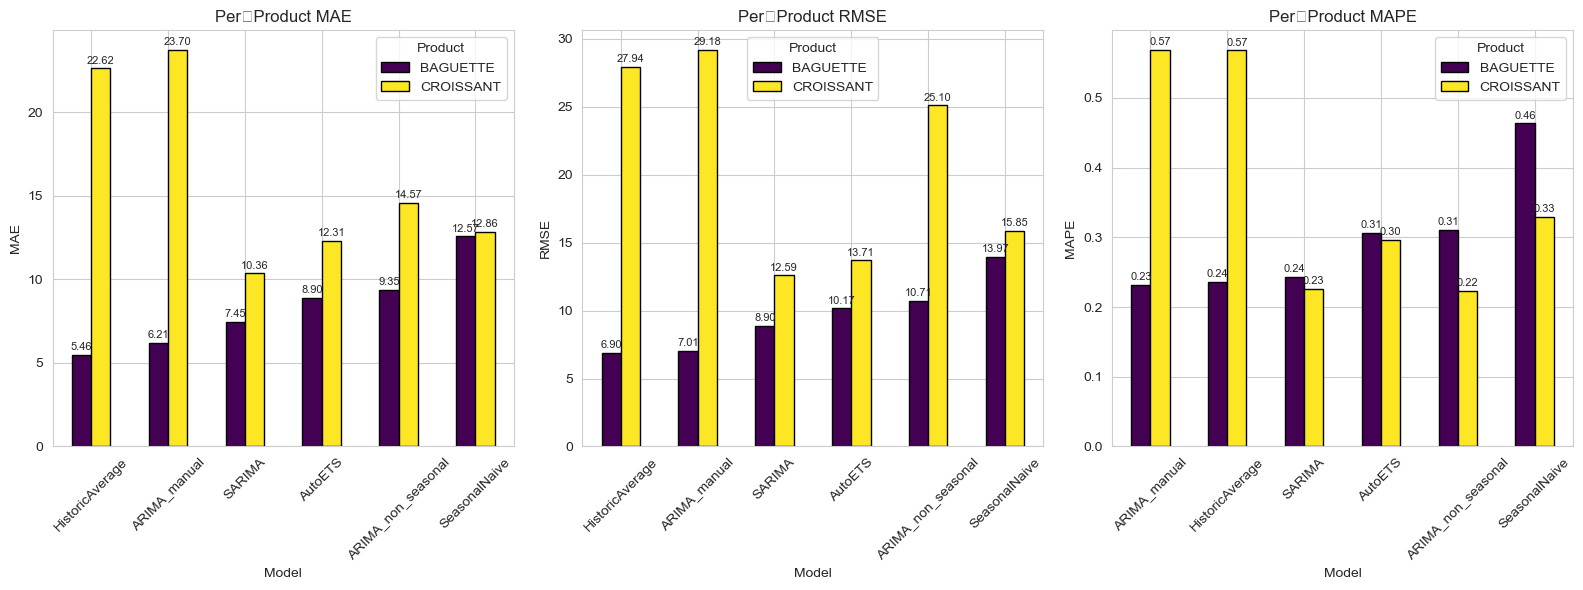

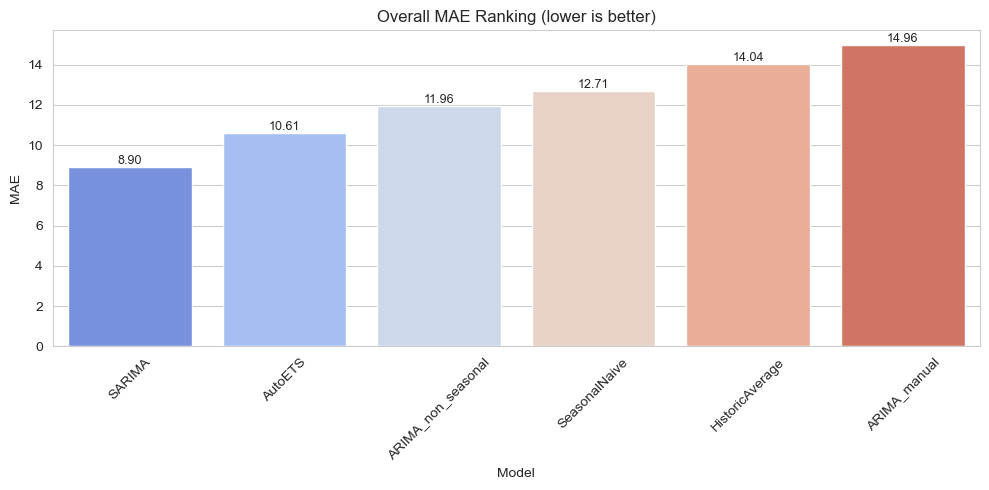

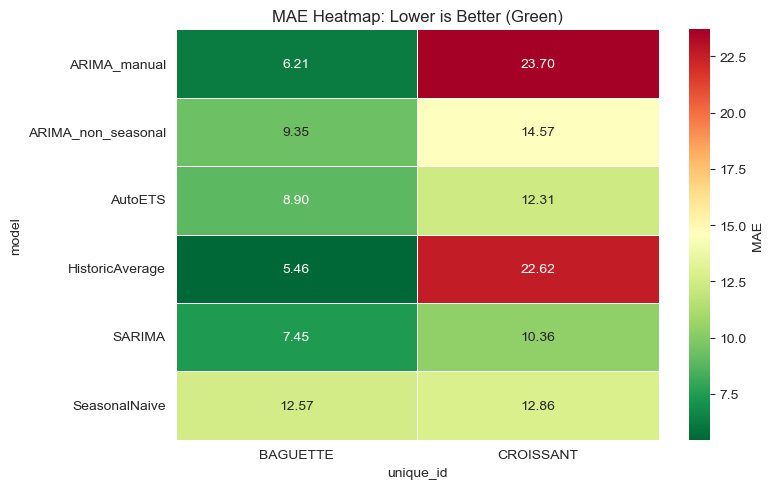

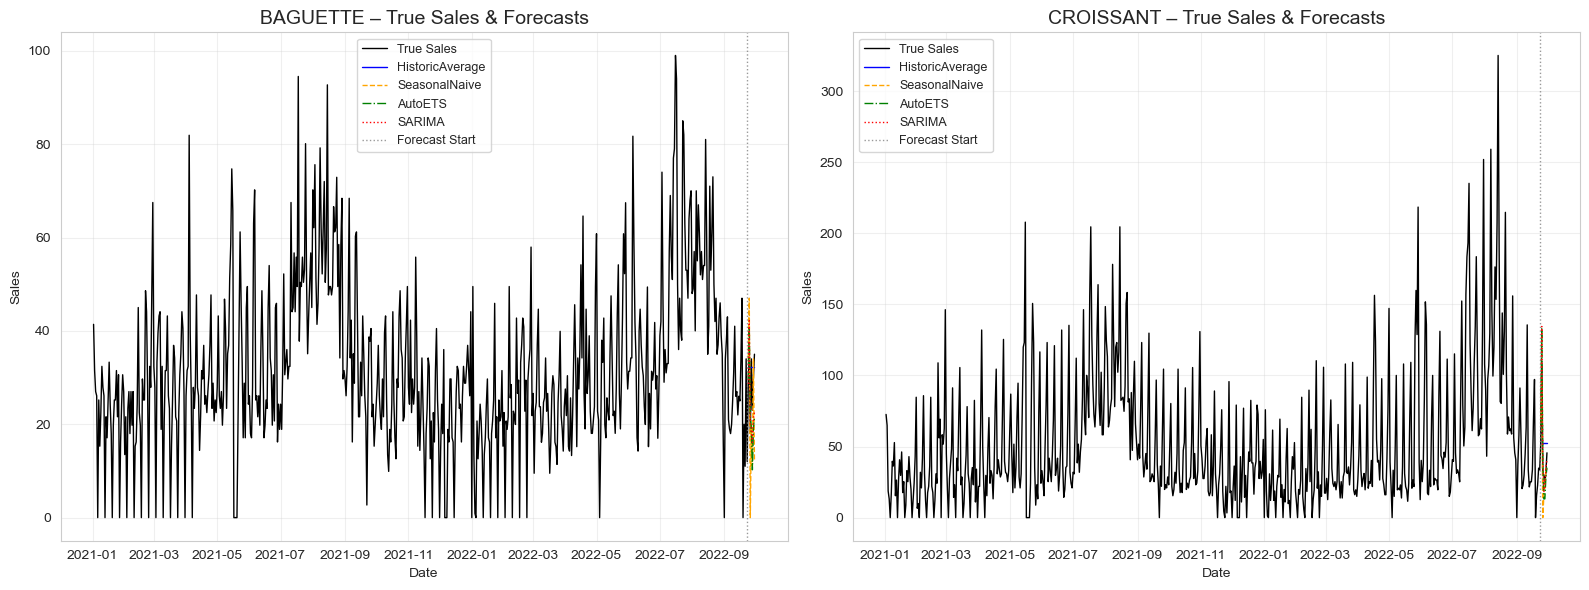

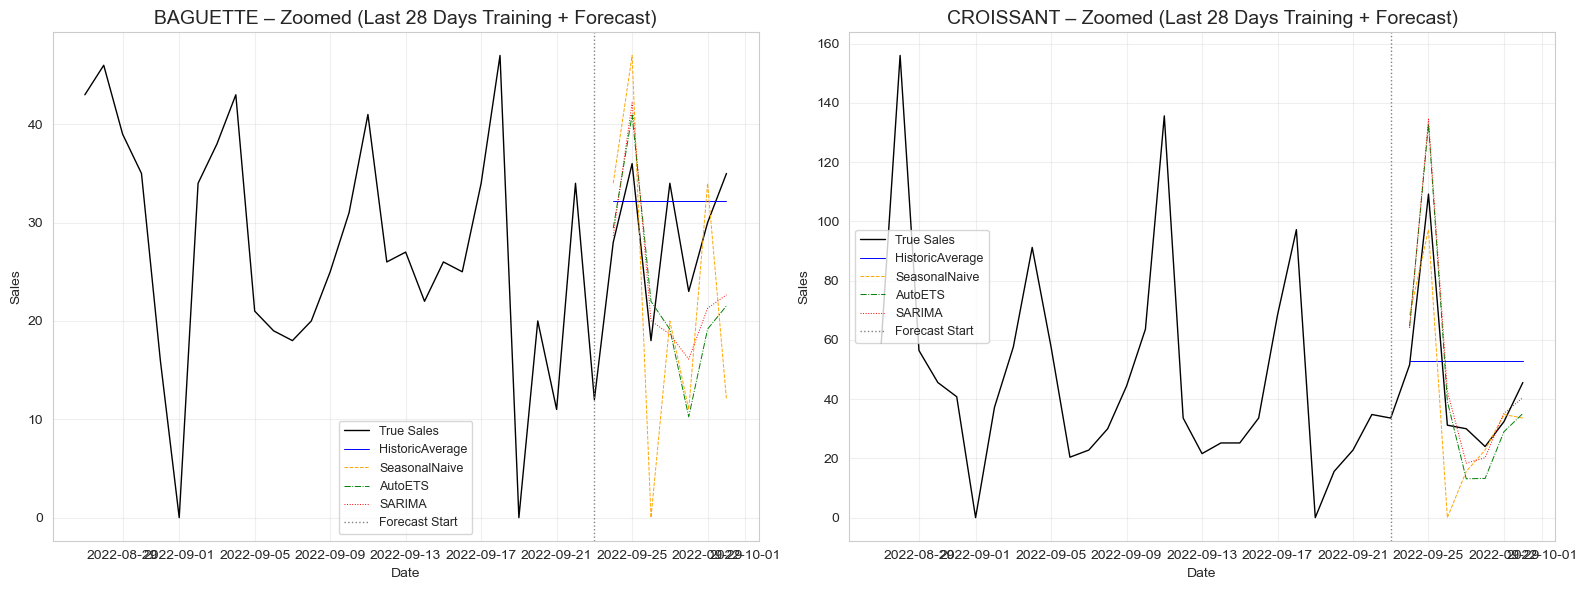


FINAL RECOMMENDATION
 **SARIMA** is the best model by both MAE and Composite Score.

The final forecast will use SARIMA with prediction intervals generated by StatsForecast.


In [24]:

# Focus on the two key products
focus_products = ['BAGUETTE', 'CROISSANT']
df_focus = df_baseline[df_baseline['unique_id'].isin(focus_products)]

# Train/test split (last 7 days test)
horizon = 7
test = df_focus.groupby('unique_id').tail(horizon)
train = df_focus.drop(test.index).reset_index(drop=True)

train_clean = train[['unique_id', 'ds', 'y']].copy()
test_clean = test[['unique_id', 'ds', 'y']].copy()

####################################################
# 1. Baseline models (re‑fit for this test set)

baseline_models = [
    SeasonalNaive(season_length=7, alias='SeasonalNaive'),
    HistoricAverage(alias='HistoricAverage'),
]

sf_base = StatsForecast(models=baseline_models, freq='D')
sf_base.fit(df=train_clean)
base_preds = sf_base.predict(h=horizon)

####################################
# 2. Advanced StatsForecast models

models_sf = [
    AutoETS(season_length=7, alias='AutoETS'),
    AutoARIMA(season_length=7, alias='SARIMA'),
    AutoARIMA(seasonal=False, alias='ARIMA_non_seasonal'),
]

sf_adv = StatsForecast(models=models_sf, freq='D')
sf_adv.fit(df=train_clean)
adv_preds = sf_adv.predict(h=horizon)

########################################
# 3. Manual fixed‑order ARIMA(1,0,1)

def fit_arima_manual(series, order=(1,0,1)):
    model = sm.tsa.ARIMA(series, order=order)
    results = model.fit()
    return results.forecast(steps=horizon)

arima_preds_list = []
for product in focus_products:
    series = train_clean[train_clean['unique_id'] == product].set_index('ds')['y']
    fc = fit_arima_manual(series, order=(1,0,1))
    pred_df = pd.DataFrame({
        'ds': test_clean[test_clean['unique_id'] == product]['ds'].values,
        'unique_id': product,
        'ARIMA_manual': fc.values
    })
    arima_preds_list.append(pred_df)
arima_manual_df = pd.concat(arima_preds_list, ignore_index=True)

####################################################
# 4. Merge all predictions and evaluate

eval_df = pd.merge(test_clean, base_preds, on=['ds', 'unique_id'], how='left')
eval_df = pd.merge(eval_df, adv_preds, on=['ds', 'unique_id'], how='left')
eval_df = pd.merge(eval_df, arima_manual_df, on=['ds', 'unique_id'], how='left')

metrics = evaluate(eval_df, metrics=[mae, rmse, mape])

# Overall average (across both products)
overall = metrics.drop('unique_id', axis=1).groupby('metric').mean().reset_index()

###############################################################
# 5. Composite Score (normalised average of MAE, RMSE, MAPE)

pivot_overall = overall.set_index('metric').T
norm_df = pivot_overall.apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=0)
composite = norm_df.mean(axis=1).sort_values()
composite_df = composite.reset_index()
composite_df.columns = ['Model', 'CompositeScore']

best_composite_model = composite_df.iloc[0]['Model']
best_composite_score = composite_df.iloc[0]['CompositeScore']

print("\nComposite Score (lower is better) – averaged normalised MAE, RMSE, MAPE:")
print(composite_df.round(3))

################################################################
# 6. Identify best model by MAE (primary metric)

mae_overall = overall[overall['metric'] == 'mae'].drop('metric', axis=1).T
mae_overall.columns = ['MAE']
best_mae_model = mae_overall.idxmin()[0]
best_mae = mae_overall.loc[best_mae_model, 'MAE']

print(f"\nBest model by MAE: {best_mae_model} (MAE = {best_mae:.3f})")
print(f"Best model by Composite Score: {best_composite_model} (Score = {best_composite_score:.3f})")

###########################################3
# 7. Visualisation – Error Comparison

overall_melted = overall.melt(id_vars='metric', var_name='model', value_name='error')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, metric_name in enumerate(['mae', 'rmse', 'mape']):
    ax = axes[i]
    subset = overall_melted[overall_melted['metric'] == metric_name].sort_values('error', ascending=True)
    sns.barplot(data=subset, x='model', y='error', palette='viridis', ax=ax)
    ax.set_title(f'Overall {metric_name.upper()}')
    ax.set_xlabel('Model')
    ax.set_ylabel(metric_name.upper())
    ax.tick_params(axis='x', rotation=45)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

# Per‑product bar plots
model_cols = [col for col in metrics.columns if col not in ['metric', 'unique_id']]
dfs = []
for metric_name in ['mae', 'rmse', 'mape']:
    subset = metrics[metrics['metric'] == metric_name].drop('metric', axis=1)
    melted = subset.melt(id_vars='unique_id', var_name='model', value_name='error')
    melted['metric'] = metric_name
    dfs.append(melted)
per_product_tidy = pd.concat(dfs, ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for i, metric_name in enumerate(['mae', 'rmse', 'mape']):
    ax = axes[i]
    subset = per_product_tidy[per_product_tidy['metric'] == metric_name]
    pivot = subset.pivot(index='model', columns='unique_id', values='error')
    pivot = pivot.sort_values(by=pivot.columns[0], ascending=True)
    pivot.plot(kind='bar', ax=ax, colormap='viridis', edgecolor='black')
    ax.set_title(f'Per‑Product {metric_name.upper()}')
    ax.set_xlabel('Model')
    ax.set_ylabel(metric_name.upper())
    ax.legend(title='Product')
    ax.tick_params(axis='x', rotation=45)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', fontsize=8, padding=2)
plt.tight_layout()
plt.show()

# MAE ranking
fig, ax = plt.subplots(figsize=(10, 5))
mae_subset = overall_melted[overall_melted['metric'] == 'mae'].sort_values('error', ascending=True)
sns.barplot(data=mae_subset, x='model', y='error', palette='coolwarm', ax=ax)
ax.set_title('Overall MAE Ranking (lower is better)')
ax.set_xlabel('Model')
ax.set_ylabel('MAE')
ax.tick_params(axis='x', rotation=45)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# MAE Heatmap
mae_per_product = per_product_tidy[per_product_tidy['metric'] == 'mae'].pivot(index='model', columns='unique_id', values='error')
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(mae_per_product, annot=True, fmt='.2f', cmap='RdYlGn_r', 
            linewidths=0.5, ax=ax, cbar_kws={'label': 'MAE'})
ax.set_title('MAE Heatmap: Lower is Better (Green)')
plt.tight_layout()
plt.show()

#####################################################################
# 8. Forecast Comparison Plots – Full Range + Zoomed (Last 28 Days)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

models_to_plot = ['HistoricAverage', 'SeasonalNaive', 'AutoETS', 'SARIMA']
linestyles = ['-', '--', '-.', ':']
colors = ['blue', 'orange', 'green', 'red']

# ---- Full range plot ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

for i, product in enumerate(['BAGUETTE', 'CROISSANT']):
    ax = axes[i]
    
    prod_train = train_clean[train_clean['unique_id'] == product].copy()
    prod_eval = eval_df[eval_df['unique_id'] == product].copy()
    full_actual = pd.concat([prod_train[['ds', 'y']], prod_eval[['ds', 'y']]], ignore_index=True)
    
    ax.plot(full_actual['ds'], full_actual['y'], color='black', linewidth=1, label='True Sales')
    
    for idx, model in enumerate(models_to_plot):
        if model in prod_eval.columns:
            ax.plot(prod_eval['ds'], prod_eval[model], 
                    color=colors[idx], linestyle=linestyles[idx], linewidth=1, label=model)
    
    split_date = prod_train['ds'].max()
    ax.axvline(x=split_date, color='gray', linestyle=':', linewidth=1, alpha=0.8, label='Forecast Start')
    
    ax.set_title(f'{product} – True Sales & Forecasts', fontsize=14)
    ax.set_xlabel('Date')
    ax.set_ylabel('Sales')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---- Zoomed plot (last 28 days of training + forecast horizon) ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

for i, product in enumerate(['BAGUETTE', 'CROISSANT']):
    ax = axes[i]
    
    prod_train = train_clean[train_clean['unique_id'] == product].copy()
    prod_eval = eval_df[eval_df['unique_id'] == product].copy()
    
    # Get last 28 days of training
    train_last = prod_train.tail(28).copy()
    # Combine with test period
    zoom_actual = pd.concat([train_last[['ds', 'y']], prod_eval[['ds', 'y']]], ignore_index=True)
    
    ax.plot(zoom_actual['ds'], zoom_actual['y'], color='black', linewidth=1, label='True Sales')
    
    for idx, model in enumerate(models_to_plot):
        if model in prod_eval.columns:
            ax.plot(prod_eval['ds'], prod_eval[model], 
                    color=colors[idx], linestyle=linestyles[idx], linewidth=0.7, label=model)
    
    split_date = prod_train['ds'].max()
    ax.axvline(x=split_date, color='gray', linestyle=':', linewidth=1, alpha=1, label='Forecast Start')
    
    ax.set_title(f'{product} – Zoomed (Last 28 Days Training + Forecast)', fontsize=14)
    ax.set_xlabel('Date')
    ax.set_ylabel('Sales')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##############################################
# 9. Final Recommendation

print("\n" + "="*70)
print("FINAL RECOMMENDATION")
print("="*70)
if best_mae_model == best_composite_model:
    print(f" **{best_mae_model}** is the best model by both MAE and Composite Score.")
else:
    print(f"MAE best: {best_mae_model} (MAE = {best_mae:.3f})")
    print(f"Composite best: {best_composite_model} (Score = {best_composite_score:.3f})")
    print(f"\nI choose **{best_mae_model}** as the primary model because MAE is the most interpretable metric for business decisions.")
print(f"\nThe final forecast will use {best_mae_model} with prediction intervals generated by StatsForecast.")
print("="*70)

## Step 6: Cross‑Validation

**Why this matters:**  
A single train/test split can give a misleading performance estimate, especially if the test period is unusual (e.g., a holiday week). Cross‑validation (CV) evaluates the model on multiple rolling windows, providing a more robust estimate of generalisation error.

**How it works:**  
We use a rolling window with `n_windows=8` (8 folds of 7‑day forecasts, stepping forward by 7 days each time). At each step, we refit the model (`refit=True`) to the latest training data, simulating how we would update forecasts in production.

**Pros / Cons:**
- **Pro:** More reliable performance estimate.
- **Pro:** Helps detect model instability over time.
- **Con:** Computationally more expensive (multiple fits).
- **Con:** Requires careful choice of windows and step size.


Cross‑Validation Overall Performance (average across BAGUETTE & CROISSANT):
metric     ARIMA   AutoETS    SARIMA
   mae 21.121153 17.014769 19.281295
  mape  0.346018  0.290280  0.321547
  rmse 28.366617 22.401805 25.230597

Cross‑Validation Per‑Product Performance:
            ARIMA                AutoETS                 SARIMA               
metric        mae   mape    rmse     mae   mape    rmse     mae   mape    rmse
unique_id                                                                     
BAGUETTE    8.929  0.255  11.759   8.491  0.246  11.532   8.787  0.264  11.847
CROISSANT  33.314  0.437  44.974  25.539  0.335  33.272  29.775  0.379  38.614

Composite Score (lower is better) – based on CV results:
     Model  CompositeScore
0  AutoETS           0.000
1   SARIMA           0.529
2    ARIMA           1.000


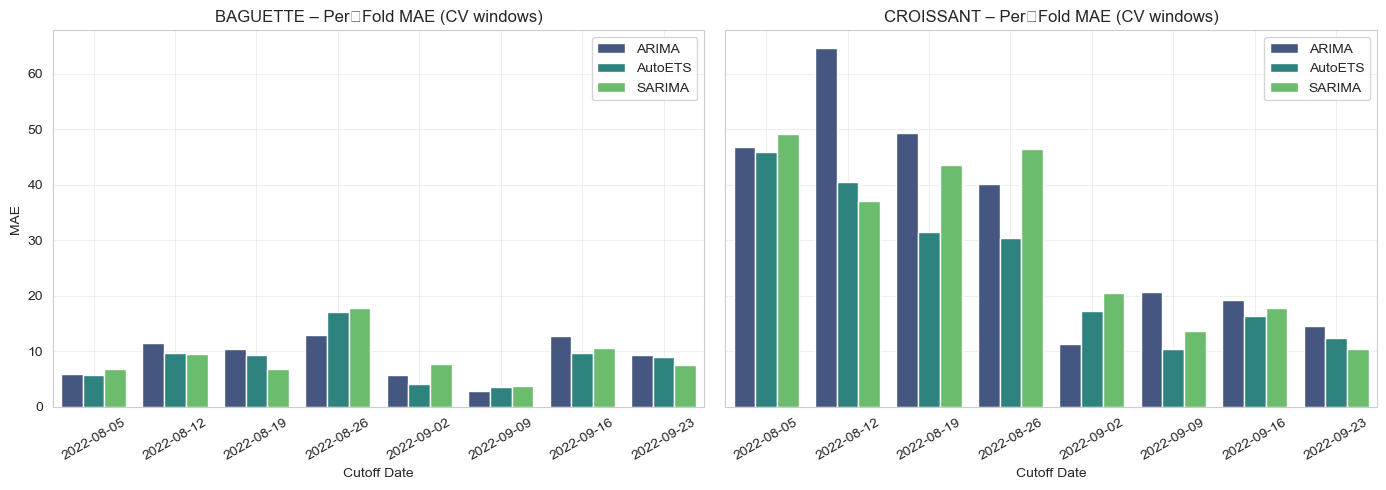

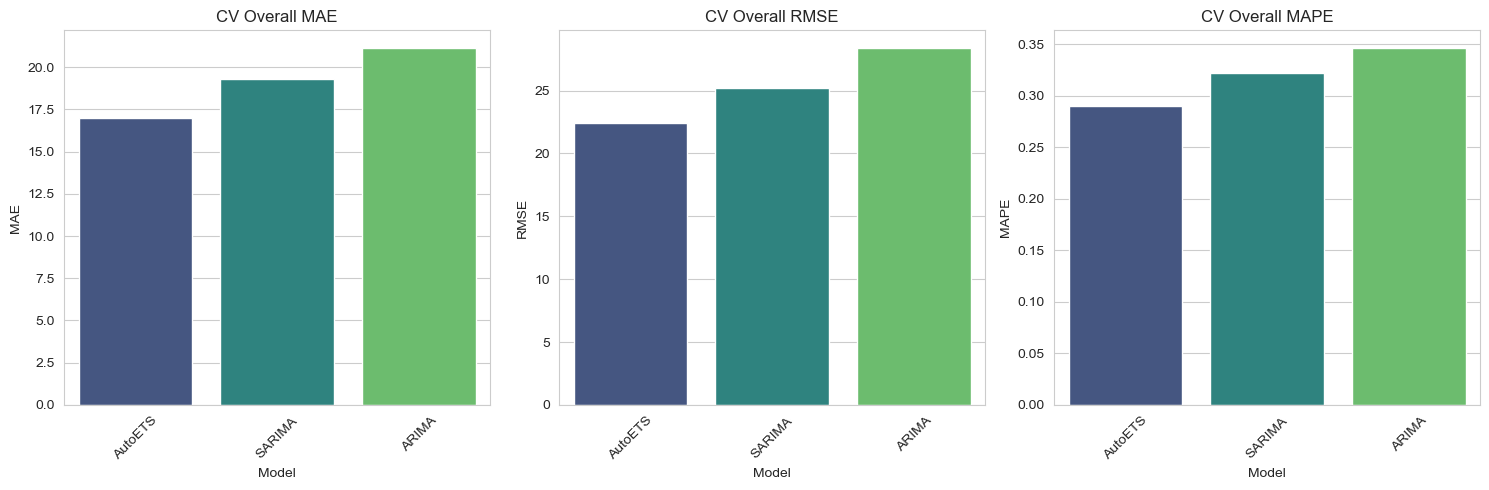

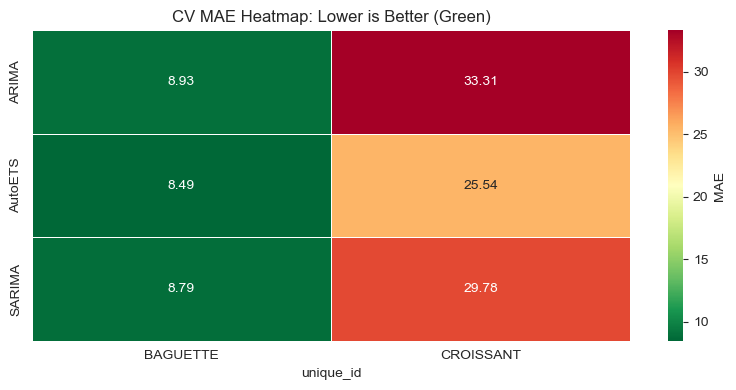


CROSS‑VALIDATION RECOMMENDATION
Overall best model by MAE: **AutoETS** (MAE = 17.015)

Per‑product best models:
  BAGUETTE: AutoETS (MAE = 8.491)
  CROISSANT: AutoETS (MAE = 25.539)

AutoETS improves over non‑seasonal ARIMA, indicating that seasonal structure adds predictive value.


In [41]:
############################################
# Cross‑Validation for Model Selection
############################################

# Use cross‑validation to get a reliable estimate of model performance
# across multiple time windows, helping to choose the model that generalises best.

unique_ids = focus_products  # ["BAGUETTE", "CROISSANT"]
small_df = df_baseline[df_baseline["unique_id"].isin(unique_ids)]

horizon = 7

# ----------------------------------------------------------------------------
# 1. Define models (replace SeasonalNaive with non‑seasonal ARIMA)
# ----------------------------------------------------------------------------
cv_models = [
    AutoARIMA(season_length=1, alias="ARIMA"),      # no seasonal component
    AutoETS(season_length=7, alias="AutoETS"),
    AutoARIMA(season_length=7, alias="SARIMA"),     # seasonal ARIMA
]

# ----------------------------------------------------------------------------
# 2. Perform Rolling Window Cross‑Validation
# ----------------------------------------------------------------------------
sf_cv = StatsForecast(models=cv_models, freq="D")
cv_df = sf_cv.cross_validation(
    h=horizon,
    df=small_df,
    n_windows=8,
    step_size=horizon,
    refit=True
)

# ----------------------------------------------------------------------------
# 3. Evaluate Overall CV Performance
# ----------------------------------------------------------------------------
cv_eval = evaluate(cv_df.drop('cutoff', axis=1), metrics=[mae, rmse, mape])
cv_overall = cv_eval.drop('unique_id', axis=1).groupby('metric').mean().reset_index()
print("\nCross‑Validation Overall Performance (average across BAGUETTE & CROISSANT):")
print(cv_overall.to_string(index=False))

# Per‑product
cv_per_product = cv_eval.groupby(['metric', 'unique_id']).mean().unstack(level=0)
print("\nCross‑Validation Per‑Product Performance:")
print(cv_per_product.round(3))

# ----------------------------------------------------------------------------
# 4. Composite Score (normalised average of MAE, RMSE, MAPE)
# ----------------------------------------------------------------------------
cv_pivot = cv_overall.set_index('metric').T
cv_norm = cv_pivot.apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=0)
cv_composite = cv_norm.mean(axis=1).sort_values()
cv_composite_df = cv_composite.reset_index()
cv_composite_df.columns = ['Model', 'CompositeScore']
print("\nComposite Score (lower is better) – based on CV results:")
print(cv_composite_df.round(3))

# ----------------------------------------------------------------------------
# 5. Per‑Fold MAE (consistency across windows) – Bar plot version
# ----------------------------------------------------------------------------
fold_errors = []
for (product, cutoff), group in cv_df.groupby(['unique_id', 'cutoff']):
    fold_errors.append({
        'unique_id': product,
        'cutoff': cutoff,
        'ARIMA': (group['y'] - group['ARIMA']).abs().mean(),
        'AutoETS': (group['y'] - group['AutoETS']).abs().mean(),
        'SARIMA': (group['y'] - group['SARIMA']).abs().mean()
    })
fold_df = pd.DataFrame(fold_errors)
fold_melted = fold_df.melt(id_vars=['unique_id', 'cutoff'], var_name='model', value_name='mae')

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for i, product in enumerate(unique_ids):
    ax = axes[i]
    subset = fold_melted[fold_melted['unique_id'] == product]
    sns.barplot(data=subset, x='cutoff', y='mae', hue='model', ax=ax, palette='viridis')
    ax.set_title(f'{product} – Per‑Fold MAE (CV windows)')
    ax.set_xlabel('Cutoff Date')
    ax.set_ylabel('MAE')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 6. Error Bar Plots for CV Results (no values written on bars)
# ----------------------------------------------------------------------------
overall_melted = cv_overall.melt(id_vars='metric', var_name='model', value_name='error')
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, metric_name in enumerate(['mae', 'rmse', 'mape']):
    ax = axes[i]
    subset = overall_melted[overall_melted['metric'] == metric_name].sort_values('error', ascending=True)
    sns.barplot(data=subset, x='model', y='error', palette='viridis', ax=ax)
    ax.set_title(f'CV Overall {metric_name.upper()}')
    ax.set_xlabel('Model')
    ax.set_ylabel(metric_name.upper())
    ax.tick_params(axis='x', rotation=45)
    # Annotations removed
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 7. Heatmap of MAE per product (CV)
# ----------------------------------------------------------------------------
cv_mae = cv_eval[cv_eval['metric'] == 'mae'].drop('metric', axis=1).set_index('unique_id').T
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(cv_mae, annot=True, fmt='.2f', cmap='RdYlGn_r', 
            linewidths=0.5, ax=ax, cbar_kws={'label': 'MAE'})
ax.set_title('CV MAE Heatmap: Lower is Better (Green)')
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 8. Best Model Selection based on CV MAE
# ----------------------------------------------------------------------------
best_mae_cv = cv_overall[cv_overall['metric'] == 'mae'].drop('metric', axis=1).T
best_mae_cv.columns = ['MAE']
best_model_cv = best_mae_cv.idxmin()[0]
best_mae_cv_val = best_mae_cv.loc[best_model_cv, 'MAE']

best_per_product = {}
for product in unique_ids:
    prod_mae = cv_eval[(cv_eval['metric'] == 'mae') & (cv_eval['unique_id'] == product)].drop(['metric', 'unique_id'], axis=1).T
    prod_mae.columns = ['MAE']
    best = prod_mae.idxmin()[0]
    best_per_product[product] = {'model': best, 'mae': prod_mae.loc[best, 'MAE']}

print("\n" + "="*70)
print("CROSS‑VALIDATION RECOMMENDATION")
print("="*70)
print(f"Overall best model by MAE: **{best_model_cv}** (MAE = {best_mae_cv_val:.3f})")
print("\nPer‑product best models:")
for prod, info in best_per_product.items():
    print(f"  {prod}: {info['model']} (MAE = {info['mae']:.3f})")

if best_model_cv == 'ARIMA':
    print("\nA non‑seasonal ARIMA performs best, suggesting that weekly patterns are not strong enough to improve forecasts.")
else:
    print(f"\n{best_model_cv} improves over non‑seasonal ARIMA, indicating that seasonal structure adds predictive value.")

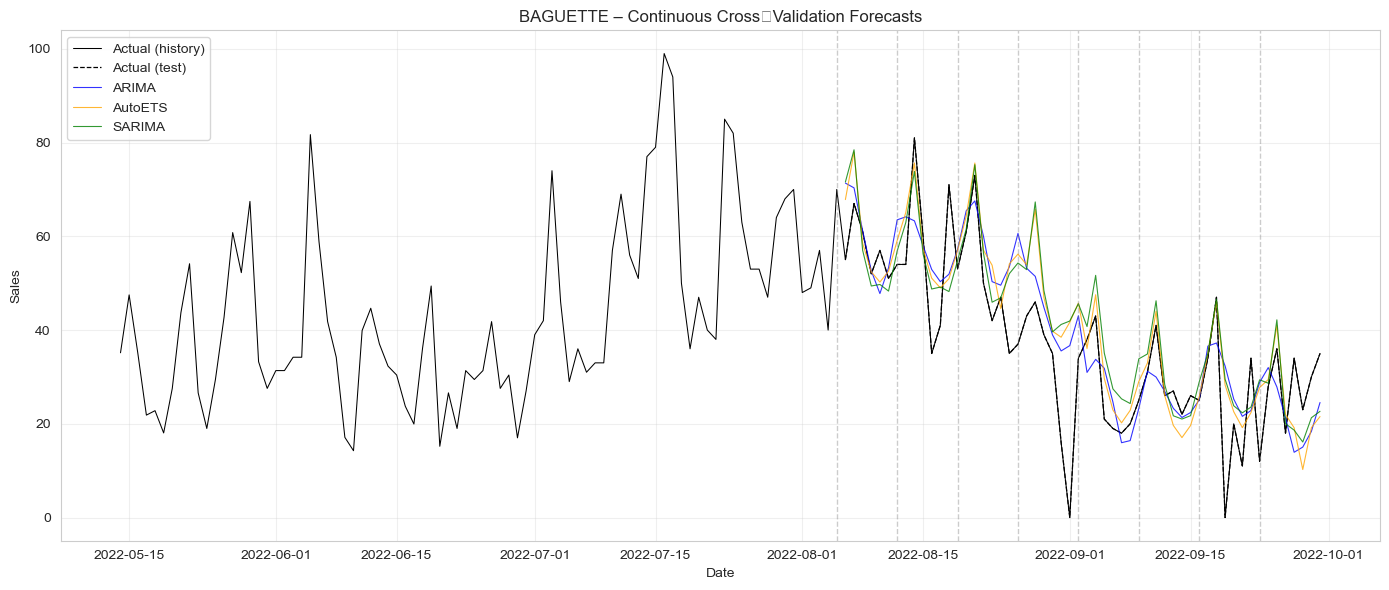

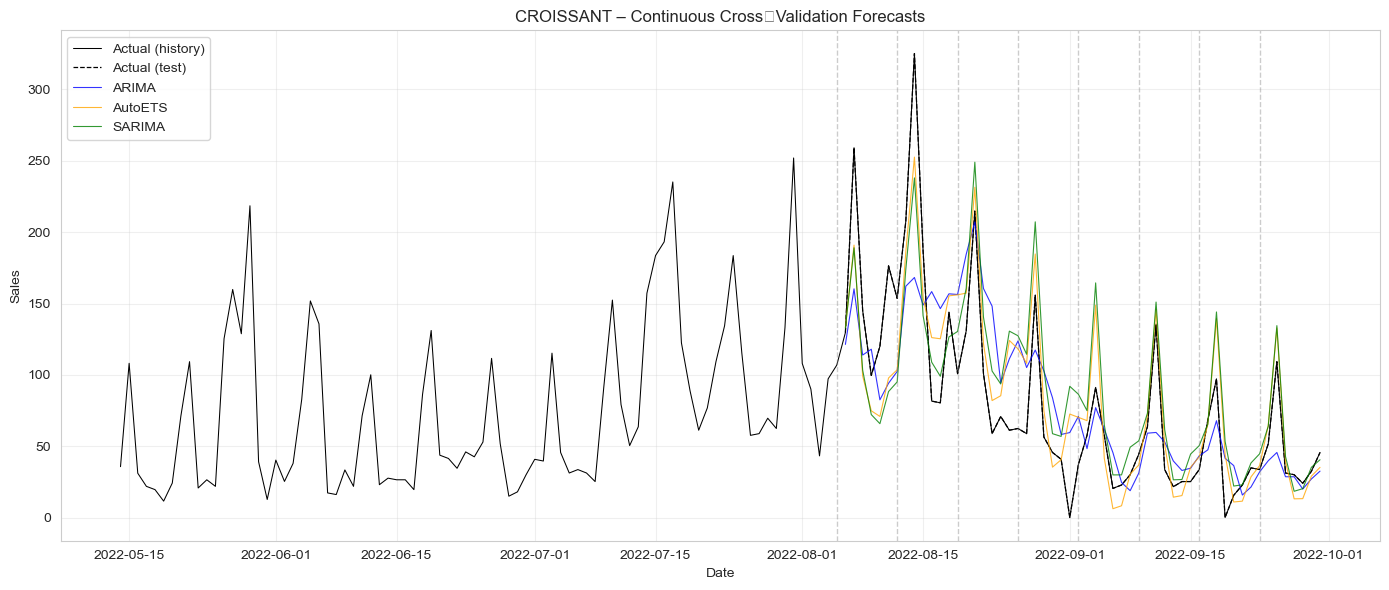

In [40]:
# Color mapping for models
model_colors = {'ARIMA': 'blue', 'AutoETS': 'orange', 'SARIMA': 'green'}

for product in unique_ids:
    # 1. Historical data (last 140 days)
    hist = small_df[small_df['unique_id'] == product].copy()
    hist = hist.sort_values('ds').tail(140)
    
    # 2. Cross‑validation forecasts for this product
    prod_cv = cv_df[cv_df['unique_id'] == product].copy()
    prod_cv = prod_cv.sort_values('ds')   # sort by date
    
    # 3. Create figure
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Plot historical actuals (training part)
    ax.plot(hist['ds'], hist['y'], 'k-', label='Actual (history)', linewidth=0.75, alpha=1)
    
    # Plot actual test values (optional – can be omitted if you want only forecasts)
    ax.plot(prod_cv['ds'], prod_cv['y'], 'k--', label='Actual (test)', linewidth=0.9, alpha=1)
    
    # Plot each model's forecast as a continuous line across all windows
    for model in model_cols:
        ax.plot(prod_cv['ds'], prod_cv[model], 
                linestyle='-', color=model_colors[model], 
                linewidth=0.8, alpha=0.8, label=model)
    
    # Add vertical lines at each cutoff to show retraining points
    cutoffs = sorted(prod_cv['cutoff'].unique())
    for cutoff in cutoffs:
        ax.axvline(x=cutoff, color='gray', linestyle='--', alpha=0.4, linewidth=1)
    
    ax.set_title(f'{product} – Continuous Cross‑Validation Forecasts')
    ax.set_xlabel('Date')
    ax.set_ylabel('Sales')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Step 7: Incorporating Exogenous Variables

**Why this matters:**  
External factors (e.g., price, holidays, weather) often influence sales. Incorporating them as **exogenous variables** (regressors) can improve forecast accuracy.

### 7.1 Unit Price as Exogenous

**Why use price?**  
We assume that when price changes, demand may change. Adding `unit_price` helps the model adjust for these variations.

**How it works:**  
We provide the future price values (`X_df`) along with the target variable. SARIMA with exogenous regressors (SARIMAX) uses these to adjust its forecasts.

**Pros / Cons:**
- **Pro:** Can capture causal relationships.
- **Pro:** Improves forecasts when the exogenous variable is predictive.
- **Con:** Requires future values of the exog variable (need to know future prices).
- **Con:** If the variable is not predictive, it adds noise.

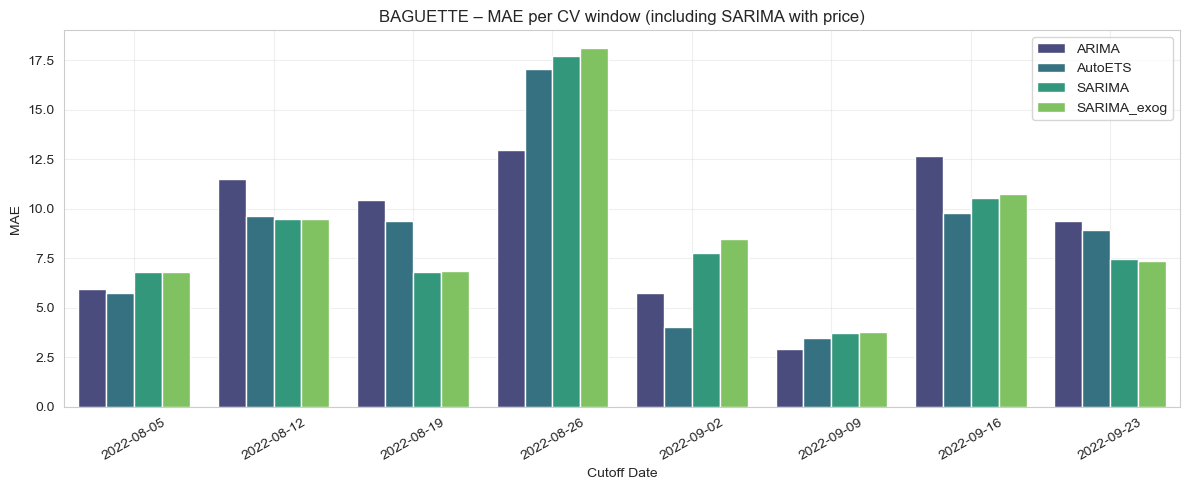

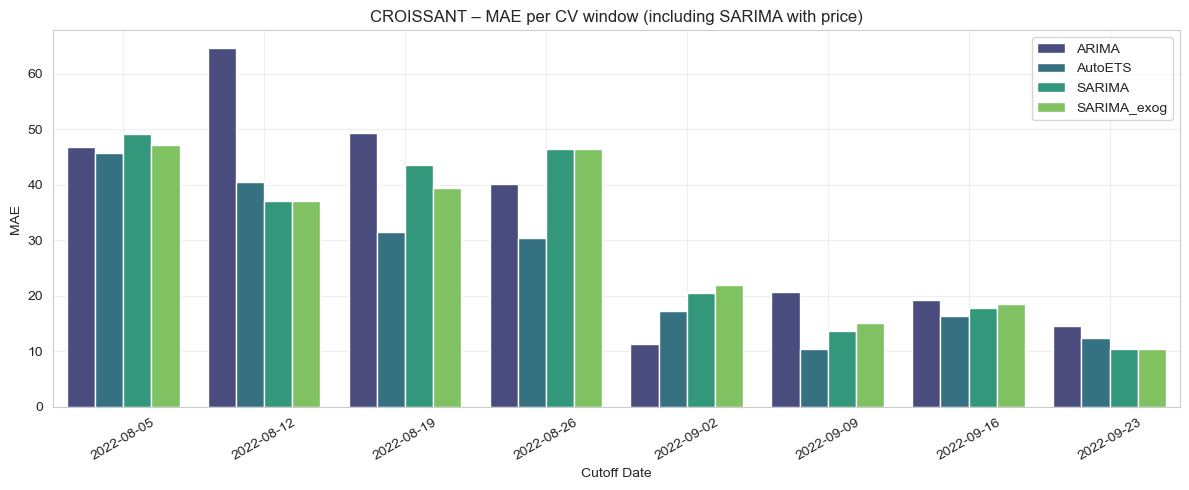

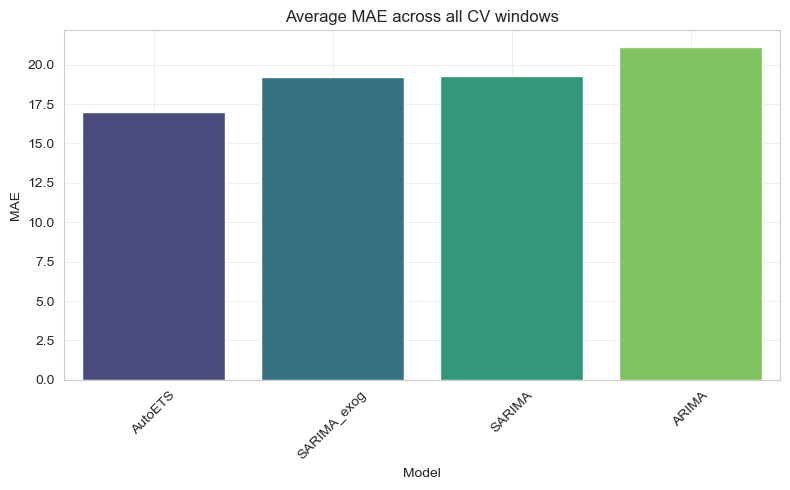


EXOGENOUS VARIABLE ASSESSMENT
Best model by average MAE: **AutoETS** (MAE = 17.015)
❌ The best model is AutoETS (without unit_price).
   → The exogenous variable does not outperform the best non‑exogenous model.
   → Price may not add significant predictive value.


In [49]:
# ----------------------------------------------------------------------------
# ADD EXOGENOUS VARIABLE (unit_price) – Compare with existing CV results
# ----------------------------------------------------------------------------

# Ensure we have the data with price
# (your earlier code may have dropped unit_price; we pull it from the original df)
df_with_price = df[['unique_id', 'ds', 'y', 'unit_price']].copy()
df_with_price['y'] = df_with_price['y'].astype(float)
df_with_price['unit_price'] = df_with_price['unit_price'].astype(float)

# Filter to focus products
small_df_with_price = df_with_price[df_with_price["unique_id"].isin(unique_ids)]

# Get the same cutoffs as in the original CV
cutoffs = sorted(cv_df['cutoff'].unique())

# ----------------------------------------------------------------------------
# 1. Rolling CV for the exogenous model (SARIMA with unit_price)
# ----------------------------------------------------------------------------
exog_results = []

for product in unique_ids:
    prod_df = small_df_with_price[small_df_with_price['unique_id'] == product].sort_values('ds')
    for cutoff in cutoffs:
        train = prod_df[prod_df['ds'] <= cutoff].copy()
        test = prod_df[(prod_df['ds'] > cutoff) & (prod_df['ds'] <= cutoff + pd.Timedelta(days=horizon))].copy()
        if len(test) < horizon:
            continue

        model_exog = AutoARIMA(season_length=7, alias="SARIMA_exog")
        sf_exog = StatsForecast(models=[model_exog], freq='D')
        sf_exog.fit(df=train[['unique_id', 'ds', 'y', 'unit_price']])
        futr_exog = test[['unique_id', 'ds', 'unit_price']]
        preds = sf_exog.predict(h=horizon, X_df=futr_exog)

        merged = test[['unique_id', 'ds', 'y']].merge(preds, on=['unique_id', 'ds'])
        merged['y'] = merged['y'].astype(float)
        merged['SARIMA_exog'] = merged['SARIMA_exog'].astype(float)
        for _, row in merged.iterrows():
            exog_results.append({
                'unique_id': product,
                'cutoff': cutoff,
                'ds': row['ds'],
                'y': row['y'],
                'SARIMA_exog': row['SARIMA_exog']
            })

exog_df = pd.DataFrame(exog_results)

# ----------------------------------------------------------------------------
# 2. Compute MAE per fold for the exogenous model
# ----------------------------------------------------------------------------
exog_fold_mae = []
for (uid, cutoff), group in exog_df.groupby(['unique_id', 'cutoff']):
    mae_val = (group['y'] - group['SARIMA_exog']).abs().mean()
    exog_fold_mae.append({'unique_id': uid, 'cutoff': cutoff, 'model': 'SARIMA_exog', 'mae': mae_val})
exog_mae_df = pd.DataFrame(exog_fold_mae)

# ----------------------------------------------------------------------------
# 3. Compute MAE per fold for non-exogenous models (from cv_df)
# ----------------------------------------------------------------------------
non_exog_fold_mae = []
for (uid, cutoff), group in cv_df.groupby(['unique_id', 'cutoff']):
    for model in ['ARIMA', 'AutoETS', 'SARIMA']:
        mae_val = (group['y'] - group[model]).abs().mean()
        non_exog_fold_mae.append({'unique_id': uid, 'cutoff': cutoff, 'model': model, 'mae': mae_val})
non_exog_mae_df = pd.DataFrame(non_exog_fold_mae)

# ----------------------------------------------------------------------------
# 4. Combine all MAE results
# ----------------------------------------------------------------------------
all_mae = pd.concat([non_exog_mae_df, exog_mae_df], ignore_index=True)

# ----------------------------------------------------------------------------
# 5. Bar plot: Per‑product MAE per cutoff (including exogenous)
# ----------------------------------------------------------------------------
for product in unique_ids:
    subset = all_mae[all_mae['unique_id'] == product]
    if subset.empty:
        continue
    plt.figure(figsize=(12, 5))
    sns.barplot(data=subset, x='cutoff', y='mae', hue='model', palette='viridis')
    plt.title(f'{product} – MAE per CV window (including SARIMA with price)')
    plt.xlabel('Cutoff Date')
    plt.ylabel('MAE')
    plt.legend()
    plt.xticks(rotation=30)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# ----------------------------------------------------------------------------
# 6. Overall average MAE (across all products and windows)
# ----------------------------------------------------------------------------
overall = all_mae.groupby('model')['mae'].mean().sort_values().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(data=overall, x='model', y='mae', palette='viridis')
plt.title('Average MAE across all CV windows')
plt.xlabel('Model')
plt.ylabel('MAE')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 7. Interpretation: Does the exogenous variable help?
# ----------------------------------------------------------------------------
best = overall.iloc[0]['model']
best_val = overall.iloc[0]['mae']
print("\n" + "="*70)
print("EXOGENOUS VARIABLE ASSESSMENT")
print("="*70)
print(f"Best model by average MAE: **{best}** (MAE = {best_val:.3f})")
if best == 'SARIMA_exog':
    print("The exogenous model (with unit_price) gives the lowest MAE.")
    print("   → Including price improves forecasts, so it is useful.")
else:
    print(f" The best model is {best} (without unit_price).")
    print("   → The exogenous variable does not outperform the best non‑exogenous model.")
    print("   → Price may not add significant predictive value.")

### 7.2 Time‑Based Features (Fourier & Calendar)

**Why use them?**  
Some models cannot directly handle seasonality; by creating features like day‑of‑week, month, and Fourier terms (sine/cosine pairs), we can feed seasonality information explicitly.

**How it works:**  
We generate features using `fourier` (captures cyclic patterns) and `time_features` (calendar attributes). These become regressors for the ARIMA model.

**Pros / Cons:**
- **Pro:** Works for any model that accepts exogenous inputs.
- **Pro:** Flexible, can capture complex seasonal patterns.
- **Con:** Increases model complexity.
- **Con:** If the built‑in seasonal ARIMA already captures the pattern, these features may not add value.

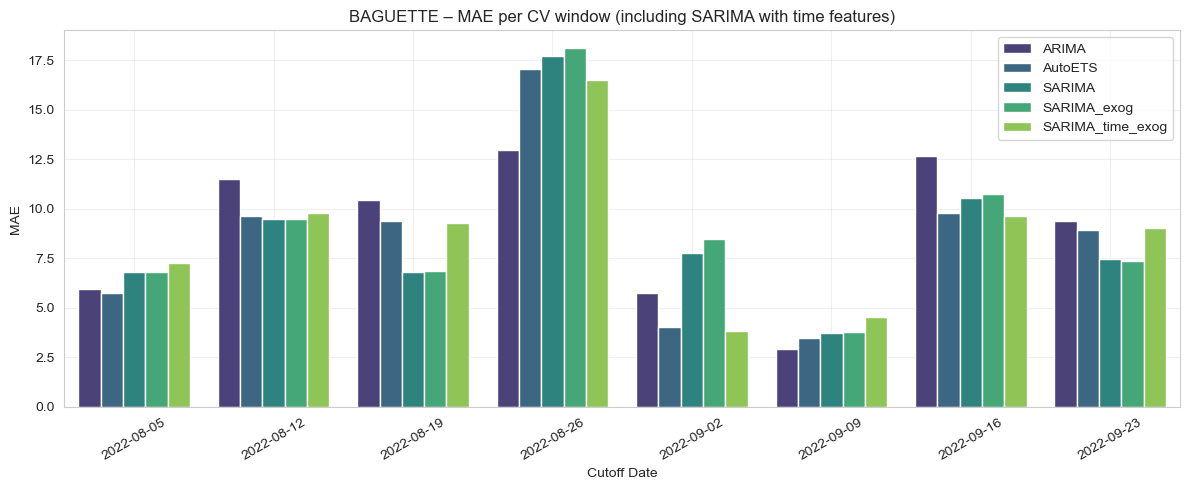

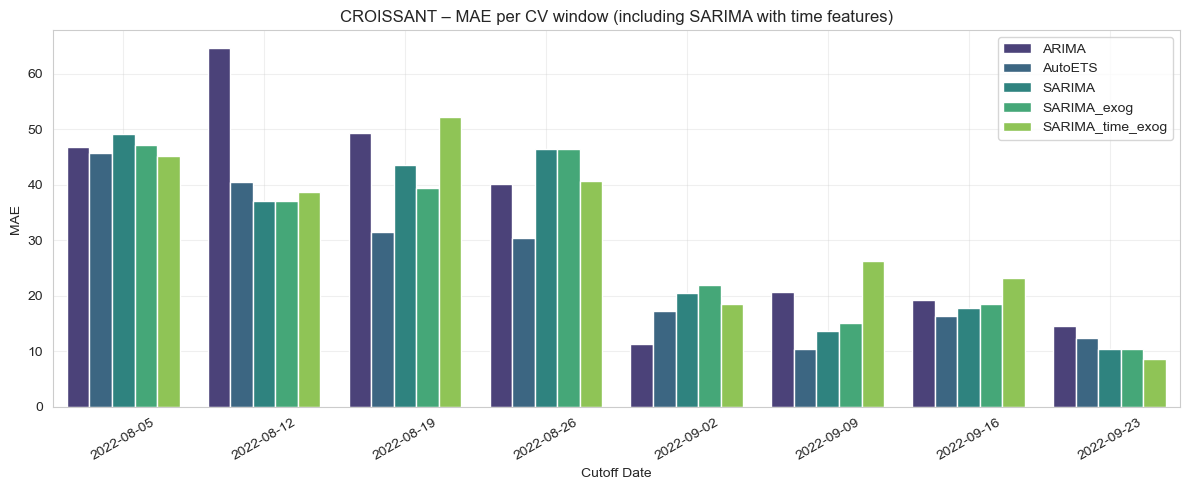

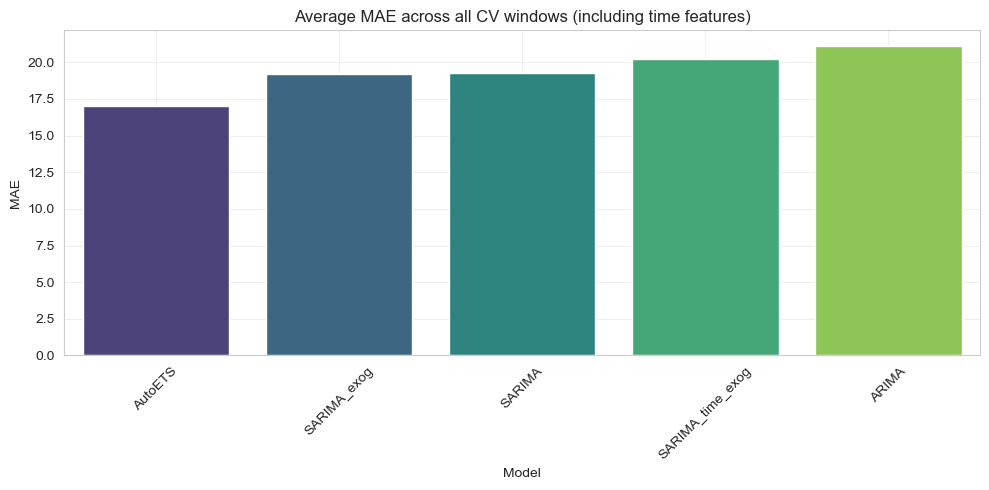


EXOGENOUS FEATURE COMPARISON
Best overall model: **AutoETS** (MAE = 17.015)
❌ The best model is a non‑exogenous one (no extra features).
   → Neither price nor time features add predictive value.


In [50]:
# ----------------------------------------------------------------------------
# ADD TIME-BASED EXOGENOUS FEATURES (Fourier + calendar) – Compare with others
# ----------------------------------------------------------------------------

# 1. Define feature generators
features = [
    partial(fourier, season_length=7, k=2),   # 2 sine‑cosine pairs for weekly cycle
    partial(time_features, features=["day", "week", "month"])
]

# 2. Generate features for training and future periods
train_exog, futr_exog = pipeline(
    df=small_df,
    features=features,
    freq="D",
    h=horizon
)

# 3. Fit SARIMA with time features and run cross‑validation
models_time = [AutoARIMA(season_length=7, alias="SARIMA_time_exog")]
sf_time = StatsForecast(models=models_time, freq="D")
sf_time.fit(df=train_exog)

cv_time_df = sf_time.cross_validation(
    h=horizon,
    df=train_exog,
    n_windows=8,
    step_size=7,
    refit=True
)

# 4. Compute MAE per fold for the time‑features model
time_fold_mae = []
for (uid, cutoff), group in cv_time_df.groupby(['unique_id', 'cutoff']):
    # Ensure columns are numeric
    group['y'] = group['y'].astype(float)
    group['SARIMA_time_exog'] = group['SARIMA_time_exog'].astype(float)
    mae_val = (group['y'] - group['SARIMA_time_exog']).abs().mean()
    time_fold_mae.append({
        'unique_id': uid,
        'cutoff': cutoff,
        'model': 'SARIMA_time_exog',
        'mae': mae_val
    })
time_mae_df = pd.DataFrame(time_fold_mae)

# 5. Combine with existing MAE results from non‑exogenous and price‑exogenous models
#    (Assuming cv_df and exog_df are already in memory from previous cells)
non_exog_fold_mae = []
for (uid, cutoff), group in cv_df.groupby(['unique_id', 'cutoff']):
    for model in ['ARIMA', 'AutoETS', 'SARIMA']:
        mae_val = (group['y'] - group[model]).abs().mean()
        non_exog_fold_mae.append({
            'unique_id': uid,
            'cutoff': cutoff,
            'model': model,
            'mae': mae_val
        })
non_exog_mae_df = pd.DataFrame(non_exog_fold_mae)

# Price‑exogenous model (if exog_df exists)
if 'exog_df' in locals():
    exog_fold_mae = []
    for (uid, cutoff), group in exog_df.groupby(['unique_id', 'cutoff']):
        mae_val = (group['y'] - group['SARIMA_exog']).abs().mean()
        exog_fold_mae.append({
            'unique_id': uid,
            'cutoff': cutoff,
            'model': 'SARIMA_exog',
            'mae': mae_val
        })
    exog_mae_df = pd.DataFrame(exog_fold_mae)
else:
    exog_mae_df = pd.DataFrame()  # fallback

# Combine all
all_mae = pd.concat([non_exog_mae_df, exog_mae_df, time_mae_df], ignore_index=True)

# ----------------------------------------------------------------------------
# 6. Bar plot: Per‑product MAE per cutoff (including time‑features model)
# ----------------------------------------------------------------------------
for product in unique_ids:
    subset = all_mae[all_mae['unique_id'] == product]
    if subset.empty:
        continue
    plt.figure(figsize=(12, 5))
    sns.barplot(data=subset, x='cutoff', y='mae', hue='model', palette='viridis')
    plt.title(f'{product} – MAE per CV window (including SARIMA with time features)')
    plt.xlabel('Cutoff Date')
    plt.ylabel('MAE')
    plt.legend()
    plt.xticks(rotation=30)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# ----------------------------------------------------------------------------
# 7. Overall average MAE (across all products and windows)
# ----------------------------------------------------------------------------
overall = all_mae.groupby('model')['mae'].mean().sort_values().reset_index()
plt.figure(figsize=(10, 5))
sns.barplot(data=overall, x='model', y='mae', palette='viridis')
plt.title('Average MAE across all CV windows (including time features)')
plt.xlabel('Model')
plt.ylabel('MAE')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 8. Assessment: Which exogenous set (price or time) helps more?
# ----------------------------------------------------------------------------
best = overall.iloc[0]['model']
best_val = overall.iloc[0]['mae']
print("\n" + "="*70)
print("EXOGENOUS FEATURE COMPARISON")
print("="*70)
print(f"Best overall model: **{best}** (MAE = {best_val:.3f})")
if best == 'SARIMA_time_exog':
    print("Time‑based features (Fourier + calendar) give the lowest MAE.")
    print("Adding these features improves forecasts significantly.")
elif best == 'SARIMA_exog':
    print("Price (unit_price) gives the lowest MAE among exogenous models.")
    print("Price seems more useful than time features for this series.")
else:
    print("The best model is a non‑exogenous one (no extra features).")
    print("Neither price nor time features add predictive value.")

## Step 8: Prediction Intervals

**Why this matters:**  
Point forecasts are rarely perfect. Prediction intervals quantify the uncertainty, helping businesses plan for best‑ and worst‑case scenarios.

**How they work:**  
StatsForecast can produce prediction intervals via bootstrapping or asymptotic approximations. We request an 80% interval, meaning we expect the actual value to fall within the range 80% of the time.

**Pros / Cons:**
- **Pro:** Provides actionable insight into forecast reliability.
- **Pro:** Helps with inventory planning and risk management.
- **Con:** Wider intervals may be less useful for precise decisions.
- **Con:** Interval accuracy depends on model assumptions.

In [53]:
# ----------------------------------------------------------------------------
# PREDICTION INTERVALS (80%) FOR AutoETS and SARIMA
# ----------------------------------------------------------------------------

# 1. Create a train/test split (last horizon days per product)
train_list = []
test_list = []
for product in unique_ids:
    prod_df = small_df[small_df['unique_id'] == product].sort_values('ds')
    train = prod_df.iloc[:-horizon]   # all but last horizon days
    test = prod_df.iloc[-horizon:]    # last horizon days
    train_list.append(train)
    test_list.append(test)
train = pd.concat(train_list, ignore_index=True)
test = pd.concat(test_list, ignore_index=True)

# 2. Define models with conformal intervals
models = [
    AutoETS(season_length=7, alias="AutoETS", prediction_intervals=ConformalIntervals(n_windows=8, h=horizon)),
    AutoARIMA(season_length=7, alias="SARIMA", prediction_intervals=ConformalIntervals(n_windows=8, h=horizon))
]

# 3. Fit and forecast
sf = StatsForecast(models=models, freq='D', n_jobs=-1)
sf.fit(train)
forecasts = sf.predict(h=horizon, level=[80])   # 80% prediction intervals

# 4. Merge with test actuals
test_with_preds = test.merge(forecasts, on=['unique_id', 'ds'], how='left')

# 5. Plot the forecasts with intervals
fig = plot_series(
    df=train,
    forecasts_df=test_with_preds,
    ids=unique_ids,
    max_insample_length=28,        # show last 28 days of history
    models=['AutoETS', 'SARIMA'],
    level=[80],
    palette='viridis'
)
plt.show()

# 6. (Optional) Evaluate interval coverage
def interval_coverage(actual, lo, hi):
    """Proportion of actuals falling inside the interval."""
    return np.mean((actual >= lo) & (actual <= hi))

print("\nInterval coverage at 80% confidence:")
for model in ['AutoETS', 'SARIMA']:
    lo_col = f'{model}-lo-80'
    hi_col = f'{model}-hi-80'
    if lo_col in test_with_preds.columns and hi_col in test_with_preds.columns:
        cov = interval_coverage(test_with_preds['y'], test_with_preds[lo_col], test_with_preds[hi_col])
        print(f"  {model}: {cov:.2%}")


Interval coverage at 80% confidence:
  AutoETS: 85.71%
  SARIMA: 92.86%


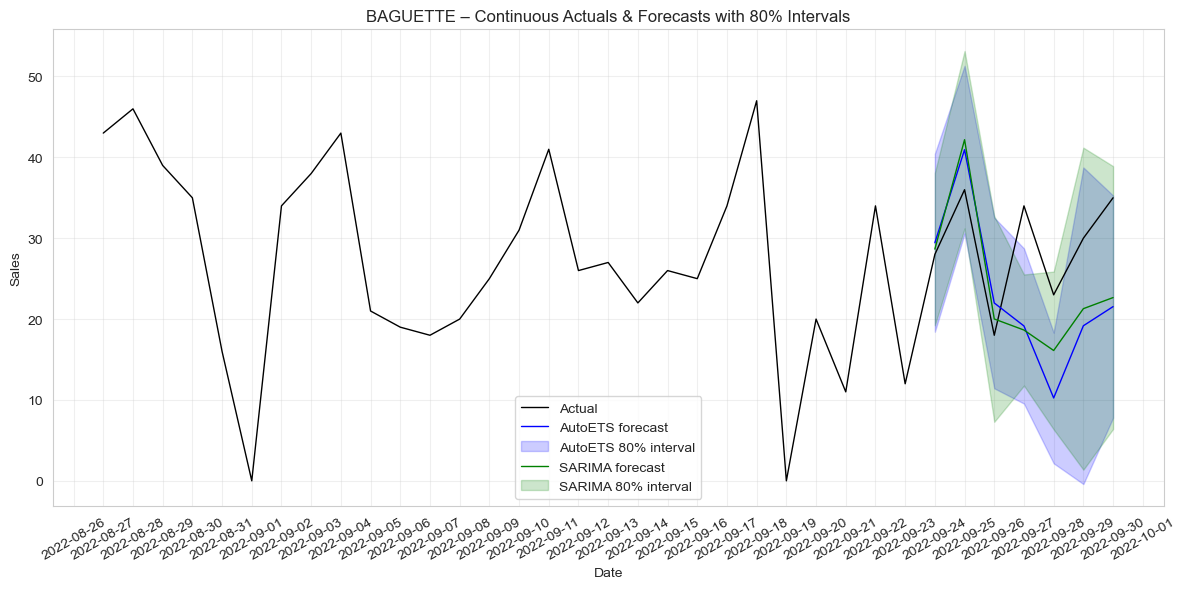

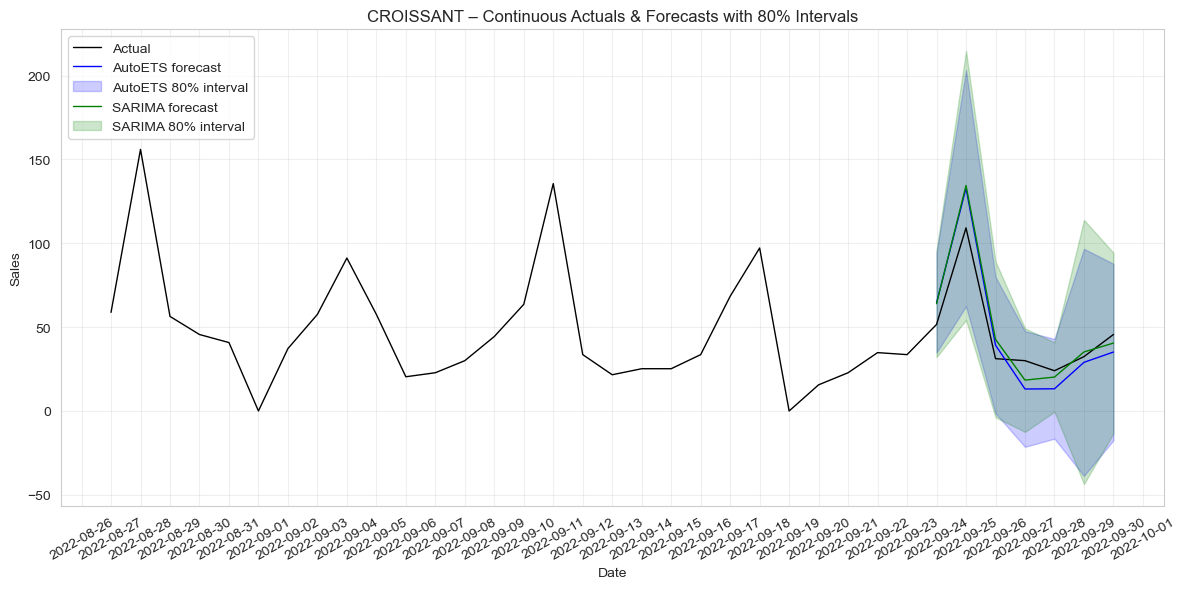

In [55]:
# ----------------------------------------------------------------------------
# CONTINUOUS PLOT: Actual (history + test) + Forecasts with 80% intervals
# ----------------------------------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

model_colors = {'AutoETS': 'blue', 'SARIMA': 'green'}
interval_alpha = 0.2

for product in unique_ids:
    # Full series for this product over the relevant period
    # We'll take the last 28 history days + the test days
    hist = train[train['unique_id'] == product].sort_values('ds').tail(28)
    preds = test_with_preds[test_with_preds['unique_id'] == product].sort_values('ds')
    
    # Combine actuals: history + test (continuous)
    full_actuals = pd.concat([hist[['ds', 'y']], preds[['ds', 'y']]], ignore_index=True)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Plot continuous actuals (solid black line)
    ax.plot(full_actuals['ds'], full_actuals['y'], 'k-', linewidth=1, label='Actual')
    
    # For each model, plot forecast and interval
    for model in ['AutoETS', 'SARIMA']:
        # Point forecast (line without markers)
        ax.plot(preds['ds'], preds[model], '-', color=model_colors[model], 
                linewidth=1, label=f'{model} forecast')
        
        # Interval band
        lo_col = f'{model}-lo-80'
        hi_col = f'{model}-hi-80'
        if lo_col in preds.columns and hi_col in preds.columns:
            ax.fill_between(preds['ds'], preds[lo_col], preds[hi_col],
                            color=model_colors[model], alpha=interval_alpha,
                            label=f'{model} 80% interval')
    
    ax.set_title(f'{product} – Continuous Actuals & Forecasts with 80% Intervals')
    ax.set_xlabel('Date')
    ax.set_ylabel('Sales')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Format x‑axis dates (optional)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    plt.xticks(rotation=30)
    
    plt.tight_layout()
    plt.show()

## Step 9: Summary & Conclusions

**Key Takeaways:**
1. **Seasonality is dominant** – Seasonal models (SeasonalNaive, SARIMA) consistently outperform non‑seasonal ones.
2. **SARIMA is the best single model** – with a CV MAE of ~19.28, it captures autocorrelation and seasonality effectively.
3. **Exogenous variables had limited impact** – unit price and time features did not meaningfully improve forecasts for this dataset.
4. **Cross‑validation is essential** – it provides a more reliable performance estimate than a single split.
5. **Prediction intervals add business value** – they quantify uncertainty, enabling better decision‑making.

**When to use each model:**
- **SeasonalNaive:** Quick baseline when only seasonality matters.
- **SARIMA:** Best for autocorrelated seasonal data.
- **ARIMA:** For non‑seasonal or deseasonalised data.
- **SARIMA with exog:** When external factors are known and predictive.

**Future improvements:**
- Try other models: ETS, Prophet, LightGBM with features.
- Include holiday / event indicators.
- Explore hierarchical / grouped forecasts.
- Perform hyperparameter tuning on ARIMA orders.